# Experiment: Cross-Method Tiny-p Study

Objective:
- Compare `iid`, `mcmc_is`, and `samc` on fixed exact scenarios.
- Track estimates and diagnostics at intermediate estimation points, not just at the final budget.

In [6]:
from __future__ import annotations

from dataclasses import replace
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "perm_pval").exists() and (candidate / "results").exists():
            return candidate
    raise RuntimeError("Could not locate project root containing perm_pval/ and results/.")


project_root = find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from perm_pval.experiments.notebook_studies import (
    BetaSweepStudyConfig,
    CrossMethodStudyConfig,
    DEFAULT_MCMC_OBJECTIVE_GRID_Q_MULTIPLIERS,
    DEFAULT_MCMC_OBJECTIVE_GRID_SWAP_COUNTS,
    MCMCWorkflowConfig,
    MCMC_OBJECTIVE_GRID_REALISTIC_OBJECTIVES,
    SAMCWorkflowConfig,
    build_beta_workflow,
    create_timestamped_run_dir,
    load_beta_sweep_saved_output,
    load_cross_method_saved_output,
    load_mcmc_objective_grid_saved_output,
    load_selected_scenarios,
    run_mcmc_objective_grid_study,
    save_mcmc_objective_grid_outputs,
    regenerate_beta_sweep_plots_from_saved,
    regenerate_cross_method_plots_from_saved,
    run_beta_checkpoint_study,
    run_cross_method_study,
    save_beta_sweep_outputs,
    save_cross_method_outputs,
    summarize_records,
)

pd.set_option("display.max_columns", 100)
project_root

PosixPath('/Users/noamchowers/Documents/University/Thesis/Code/MCMCIS')

## Configuration

`ESTIMATION_POINTS` controls the intermediate checkpoints.  
The largest checkpoint is used for the main boxplots; all checkpoints are used for convergence diagnostics.  
In the cross-method notebook these are total budgets. For MCMC-IS, a fixed beta-selection budget is deducted first, and the production chain uses the remaining budget.

In [7]:
FAST_MODE = False
SAVE_OUTPUTS = True

CATALOG_PATH = project_root / "results" / "exact_scenarios" / "v1" / "catalog.json"
OUTPUT_ROOT = project_root / "results" / "cross_method_notebook"

SCENARIO_GROUP = "core_claim"
SCENARIO_KEYS_OVERRIDE = [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "rank_sum_dp_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22",
]

ESTIMATION_POINTS = (750_000, 1_000_000, 2_500_000, 5_000_000, 7_500_000, 10_000_000, 15_000_000) if not FAST_MODE else (50_000, 100_000, 200_000)
N_REPEATS = 10 if not FAST_MODE else 2
N_JOBS = min(N_REPEATS, os.cpu_count() or 1)
MIN_TAIL_STATES = 2
BASE_SEED = 12_345
MCMC_LOCAL_SCAN_OBJECTIVE = "varhat_qmatch_soft"
MCMC_PROPOSAL_SIZE_BY_SAMPLE_BAND = {
    "small": 1,
    "medium": 1,
    "large": 2,
}
MCMC_LOCAL_SCAN_Q_MULTIPLIERS = (0.001, 0.005, 0.01, 0.05, 0.10, 0.15, 0.25, 0.33, 1.0)

cross_cfg = CrossMethodStudyConfig(
    estimation_points=ESTIMATION_POINTS,
    repeats=N_REPEATS,
    base_seed=BASE_SEED,
    iid_density_samples=150_000 if not FAST_MODE else 10_000,
    min_tail_states=MIN_TAIL_STATES,
    n_jobs=N_JOBS,
)
base_mcmc_cfg = MCMCWorkflowConfig(
    pilot_samples=25_000 if not FAST_MODE else 1_000,
    tune_steps=3_000 if not FAST_MODE else 1_000,
    local_scan_screen_total_steps=14_000 if not FAST_MODE else 1_000,
    local_scan_total_steps=32_000 if not FAST_MODE else 6_000,
    chains=2,
    thin=1,
    estimate_variance=True,
    proposal_size=1,
    local_scan_objective=MCMC_LOCAL_SCAN_OBJECTIVE,
    local_scan_q_multipliers=MCMC_LOCAL_SCAN_Q_MULTIPLIERS,
)
samc_cfg = SAMCWorkflowConfig(
    n_bins=100,
    t0=1_000.0,
    trace_every=200 if not FAST_MODE else 50,
    lambda_min_pilot=10_000 if not FAST_MODE else 500,
    proposal_size=0.1,
)

def mcmc_proposal_size_for_scenario(scenario):
    band = str(scenario.portfolio.get("sample_size_band", "medium"))
    return int(MCMC_PROPOSAL_SIZE_BY_SAMPLE_BAND.get(band, 1))


def mcmc_cfg_for_scenario(scenario):
    proposal_size = int(mcmc_proposal_size_for_scenario(scenario))
    return replace(
        base_mcmc_cfg,
        proposal_size=proposal_size,
        local_scan_swap_counts=(proposal_size,),
    )

print(json.dumps({
    "FAST_MODE": FAST_MODE,
    "SCENARIO_GROUP": SCENARIO_GROUP,
    "SCENARIO_KEYS_OVERRIDE": SCENARIO_KEYS_OVERRIDE,
    "ESTIMATION_POINTS": ESTIMATION_POINTS,
    "N_REPEATS": N_REPEATS,
    "N_JOBS": N_JOBS,
    "SAVE_OUTPUTS": SAVE_OUTPUTS,
    "MCMC_LOCAL_SCAN_OBJECTIVE": MCMC_LOCAL_SCAN_OBJECTIVE,
    "MCMC_LOCAL_SCAN_Q_MULTIPLIERS": MCMC_LOCAL_SCAN_Q_MULTIPLIERS,
    "MCMC_PROPOSAL_SIZE_BY_SAMPLE_BAND": MCMC_PROPOSAL_SIZE_BY_SAMPLE_BAND,
}, indent=2))

{
  "FAST_MODE": false,
  "SCENARIO_GROUP": "core_claim",
  "SCENARIO_KEYS_OVERRIDE": [
    "hypergeom_1e7",
    "gwas_additive_score_n40",
    "rank_sum_dp_n40",
    "linear_stat_dp_n40",
    "bruteforce_welch_nonextreme_n22"
  ],
  "ESTIMATION_POINTS": [
    750000,
    1000000,
    2500000,
    5000000,
    7500000,
    10000000,
    15000000
  ],
  "N_REPEATS": 10,
  "N_JOBS": 8,
  "SAVE_OUTPUTS": true,
  "MCMC_LOCAL_SCAN_OBJECTIVE": "varhat_qmatch_soft",
  "MCMC_LOCAL_SCAN_Q_MULTIPLIERS": [
    0.001,
    0.005,
    0.01,
    0.05,
    0.1,
    0.15,
    0.25,
    0.33,
    1.0
  ],
  "MCMC_PROPOSAL_SIZE_BY_SAMPLE_BAND": {
    "small": 1,
    "medium": 1,
    "large": 2
  }
}


## Load Scenarios

In [8]:
scenarios = load_selected_scenarios(
    catalog_path=CATALOG_PATH,
    scenario_keys=SCENARIO_KEYS_OVERRIDE,
    portfolio_group=None if SCENARIO_KEYS_OVERRIDE is not None else SCENARIO_GROUP,
    min_tail_states=MIN_TAIL_STATES,
)

run_dir = create_timestamped_run_dir(OUTPUT_ROOT, "cross_method") if SAVE_OUTPUTS else None

pd.DataFrame([
    {
        "scenario": s.key,
        "exact_p": s.exact_p,
        "tail_hits": s.exact_tail_hits,
        "n_perm": s.exact_n_perm,
        "exact_method": s.exact_method,
        "family": s.portfolio.get("family"),
        "rarity_band": s.portfolio.get("rarity_band"),
        "difficulty": s.portfolio.get("expected_difficulty"),
        "groups": ",".join(s.portfolio.get("groups", [])),
    }
    for s in scenarios
])

,scenario,exact_p,tail_hits,n_perm,exact_method,family,rarity_band,difficulty,groups
0,hypergeom_1e7,3.854286e-07,53130,137846528820,Fisher exact test (2x2; hypergeometric tail),hypergeometric_tail,extreme,hard,"exploratory_exact,core_claim,stress_test"
1,gwas_additive_score_n40,9.121811e-07,125741,137846528820,LinearStatisticDPSolver,gwas_additive_score,extreme,hard,"exploratory_exact,core_claim,stress_test"
2,rank_sum_dp_n40,8.445624e-08,11642,137846528820,RankSumDPSolver,rank_sum_dp,extreme,moderate,"core_claim,exploratory_exact"
3,linear_stat_dp_n40,8.124978e-09,1120,137846528820,LinearStatisticDPSolver,linear_stat_dp,ultra_rare,hard,"core_claim,stress_test,exploratory_exact"
4,bruteforce_welch_nonextreme_n22,1.559328e-05,11,705432,BruteForceExactSolver,welch_bruteforce,very_rare,hard,"exploratory_exact,core_claim,stress_test"


## Run Cross-Method Study

For each scenario:
- build one MCMC-IS beta workflow,
- evaluate all methods at every checkpoint in `ESTIMATION_POINTS`,
- save max-budget and convergence plots.

In [9]:
cross_results = {}

for scenario in scenarios:
    scenario_mcmc_cfg = mcmc_cfg_for_scenario(scenario)
    print(f"Running {scenario.key} | exact p={scenario.exact_p:.3e}")
    print(json.dumps({
        "scenario": scenario.key,
        "sample_size_band": scenario.portfolio.get("sample_size_band"),
        "mcmc_proposal_size": scenario_mcmc_cfg.proposal_size,
        "mcmc_local_scan_swap_counts": scenario_mcmc_cfg.local_scan_swap_counts,
        "mcmc_local_scan_objective": scenario_mcmc_cfg.local_scan_objective,
    }, indent=2))
    study = run_cross_method_study(
        scenario,
        cross_cfg=cross_cfg,
        mcmc_cfg=scenario_mcmc_cfg,
        samc_cfg=samc_cfg,
    )
    cross_results[scenario.key] = study

    if SAVE_OUTPUTS and run_dir is not None:
        save_cross_method_outputs(
            scenario,
            study,
            output_dir=run_dir / scenario.key,
            cross_cfg=cross_cfg,
            mcmc_cfg=scenario_mcmc_cfg,
            samc_cfg=samc_cfg,
        )

    print(json.dumps({
        "scenario": scenario.key,
        "mcmc_beta_selection_budget": study["mcmc_beta_selection_budget"],
        "beta_used": study["beta_workflow"]["beta_used"],
    }, indent=2))
    summary_df = pd.DataFrame(study["summary"]).sort_values(["checkpoint", "method"])
    display(summary_df[[
        "checkpoint",
        "method",
        "mean_estimate",
        "rmse",
        "mean_variance_estimate",
        "mean_eval_incl_tuning",
        "mean_q_tilt_tail_share",
        "mean_ess",
        "mean_zero_rate",
        "mean_samc_max_rel_freq_error",
    ]])

family_rows = []
for scenario in scenarios:
    meta = scenario.portfolio
    for row in cross_results[scenario.key]["summary"]:
        family_rows.append({
            "scenario": scenario.key,
            "family": meta.get("family"),
            "rarity_band": meta.get("rarity_band"),
            "difficulty": meta.get("expected_difficulty"),
            **row,
        })

family_df = pd.DataFrame(family_rows)
display(
    family_df.groupby(["family", "rarity_band", "method", "checkpoint"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_estimate=("mean_estimate", "mean"),
        mean_q_tilt_tail_share=("mean_q_tilt_tail_share", "mean"),
        mean_ess=("mean_ess", "mean"),
    )
    .sort_values(["family", "rarity_band", "checkpoint", "method"])
)

Running hypergeom_1e7 | exact p=3.854e-07
{
  "scenario": "hypergeom_1e7",
  "sample_size_band": "medium",
  "mcmc_proposal_size": 1,
  "mcmc_local_scan_swap_counts": [
    1
  ],
  "mcmc_local_scan_objective": "varhat_qmatch_soft"
}
{
  "scenario": "hypergeom_1e7",
  "mcmc_beta_selection_budget": 247015,
  "beta_used": 2.71728515625
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,750000,iid,6.666667e-07,7.235601e-07,1.777775e-12,750000.0,6.666667e-07,NaN,0.5,NaN
1,750000,mcmc_is,3.896155e-07,3.752748e-08,2.175378e-15,750000.0,5.477709e-03,1418.401499,NaN,NaN
2,750000,samc,4.254398e-07,1.750398e-07,7.090660e-13,750001.0,NaN,NaN,NaN,0.922400
3,1000000,iid,5.000000e-07,5.129587e-07,9.999990e-13,1000000.0,5.000000e-07,NaN,0.5,NaN
4,1000000,mcmc_is,3.841266e-07,2.415523e-08,1.778071e-15,1000000.0,5.412333e-03,1938.547721,NaN,NaN
5,1000000,samc,3.176581e-07,1.166662e-07,3.970725e-13,1000001.0,NaN,NaN,NaN,0.567400
6,2500000,iid,5.600000e-07,5.107594e-07,2.799997e-13,2500000.0,5.600000e-07,NaN,0.2,NaN
7,2500000,mcmc_is,3.860987e-07,2.100061e-08,5.568005e-16,2500000.0,5.494713e-03,5059.834482,NaN,NaN
8,2500000,samc,3.654094e-07,9.525681e-08,1.827046e-13,2500001.0,NaN,NaN,NaN,0.391510
9,5000000,iid,4.200000e-07,4.252002e-07,1.049999e-13,5000000.0,4.200000e-07,NaN,0.2,NaN


Running gwas_additive_score_n40 | exact p=9.122e-07
{
  "scenario": "gwas_additive_score_n40",
  "sample_size_band": "medium",
  "mcmc_proposal_size": 1,
  "mcmc_local_scan_swap_counts": [
    1
  ],
  "mcmc_local_scan_objective": "varhat_qmatch_soft"
}
{
  "scenario": "gwas_additive_score_n40",
  "mcmc_beta_selection_budget": 247015,
  "beta_used": 2.634765625
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,750000,iid,1.466667e-06,1.915060e-06,3.911096e-12,750000.0,1.466667e-06,NaN,0.5,NaN
1,750000,mcmc_is,9.321170e-07,7.216487e-08,8.694736e-15,750000.0,4.380855e-03,2275.354409,NaN,NaN
2,750000,samc,8.797724e-07,2.846235e-07,1.466286e-12,750001.0,NaN,NaN,NaN,0.802400
3,1000000,iid,1.300000e-06,1.600126e-06,2.166660e-12,1000000.0,1.300000e-06,NaN,0.4,NaN
4,1000000,mcmc_is,9.331081e-07,7.015078e-08,5.888265e-15,1000000.0,4.396508e-03,3158.367519,NaN,NaN
5,1000000,samc,1.004804e-06,3.416092e-07,1.256004e-12,1000001.0,NaN,NaN,NaN,0.697850
6,2500000,iid,9.600000e-07,5.446895e-07,3.839995e-13,2500000.0,9.600000e-07,NaN,0.0,NaN
7,2500000,mcmc_is,9.141385e-07,4.100760e-08,2.156896e-15,2500000.0,4.319960e-03,6606.900609,NaN,NaN
8,2500000,samc,8.745564e-07,1.699617e-07,4.372778e-13,2500001.0,NaN,NaN,NaN,0.431970
9,5000000,iid,9.400000e-07,3.913744e-07,1.879998e-13,5000000.0,9.400000e-07,NaN,0.0,NaN


Running rank_sum_dp_n40 | exact p=8.446e-08
{
  "scenario": "rank_sum_dp_n40",
  "sample_size_band": "medium",
  "mcmc_proposal_size": 1,
  "mcmc_local_scan_swap_counts": [
    1
  ],
  "mcmc_local_scan_objective": "varhat_qmatch_soft"
}
{
  "scenario": "rank_sum_dp_n40",
  "mcmc_beta_selection_budget": 247015,
  "beta_used": 3.2451171875
}


...

Running linear_stat_dp_n40 | exact p=8.125e-09
{
  "scenario": "linear_stat_dp_n40",
  "sample_size_band": "medium",
  "mcmc_proposal_size": 1,
  "mcmc_local_scan_swap_counts": [
    1
  ],
  "mcmc_local_scan_objective": "varhat_qmatch_soft"
}
{
  "scenario": "linear_stat_dp_n40",
  "mcmc_beta_selection_budget": 247015,
  "beta_used": 3.8525390625
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,750000,iid,0.000000e+00,8.124978e-09,NaN,750000.0,0.000000,NaN,1.0,NaN
1,750000,mcmc_is,9.215323e-09,3.493930e-09,5.800980e-18,750000.0,0.001174,179.921948,NaN,NaN
2,750000,samc,6.810783e-09,2.300135e-09,1.135130e-14,750001.0,NaN,NaN,NaN,5.116667
3,1000000,iid,0.000000e+00,8.124978e-09,NaN,1000000.0,0.000000,NaN,1.0,NaN
4,1000000,mcmc_is,8.375387e-09,2.114882e-09,4.832572e-18,1000000.0,0.001177,160.178426,NaN,NaN
5,1000000,samc,7.801475e-09,2.351005e-09,9.751843e-15,1000001.0,NaN,NaN,NaN,5.543750
6,2500000,iid,0.000000e+00,8.124978e-09,NaN,2500000.0,0.000000,NaN,1.0,NaN
7,2500000,mcmc_is,8.630774e-09,1.495041e-09,2.291327e-18,2500000.0,0.001184,336.728482,NaN,NaN
8,2500000,samc,7.470126e-09,1.476601e-09,3.735063e-15,2500001.0,NaN,NaN,NaN,3.414000
9,5000000,iid,0.000000e+00,8.124978e-09,NaN,5000000.0,0.000000,NaN,1.0,NaN


Running bruteforce_welch_nonextreme_n22 | exact p=1.559e-05
{
  "scenario": "bruteforce_welch_nonextreme_n22",
  "sample_size_band": "small",
  "mcmc_proposal_size": 1,
  "mcmc_local_scan_swap_counts": [
    1
  ],
  "mcmc_local_scan_objective": "varhat_qmatch_soft"
}
{
  "scenario": "bruteforce_welch_nonextreme_n22",
  "mcmc_beta_selection_budget": 247015,
  "beta_used": 1.43408203125
}


,checkpoint,method,mean_estimate,rmse,mean_variance_estimate,mean_eval_incl_tuning,mean_q_tilt_tail_share,mean_ess,mean_zero_rate,mean_samc_max_rel_freq_error
0,750000,iid,0.000015,2.403338e-06,2.062190e-11,750000.0,0.000015,NaN,0.0,NaN
1,750000,mcmc_is,0.000016,8.438820e-07,6.634605e-13,750000.0,0.020103,5.127941e+04,NaN,NaN
2,750000,samc,0.000015,1.676125e-06,2.506610e-11,750001.0,NaN,NaN,NaN,2.838733
3,1000000,iid,0.000015,2.352302e-06,1.509977e-11,1000000.0,0.000015,NaN,0.0,NaN
4,1000000,mcmc_is,0.000016,9.600996e-07,4.530642e-13,1000000.0,0.020319,7.561529e+04,NaN,NaN
5,1000000,samc,0.000015,1.474293e-06,1.848946e-11,1000001.0,NaN,NaN,NaN,2.092325
6,2500000,iid,0.000015,2.067903e-06,5.887912e-12,2500000.0,0.000015,NaN,0.0,NaN
7,2500000,mcmc_is,0.000016,5.619243e-07,1.510723e-13,2500000.0,0.020335,2.180847e+05,NaN,NaN
8,2500000,samc,0.000016,6.222506e-07,7.891975e-12,2500001.0,NaN,NaN,NaN,1.614220
9,5000000,iid,0.000015,2.033051e-06,2.959955e-12,5000000.0,0.000015,NaN,0.0,NaN


,family,rarity_band,method,checkpoint,mean_rmse,mean_estimate,mean_q_tilt_tail_share,mean_ess
0,gwas_additive_score,extreme,iid,750000,1.915060e-06,1.466667e-06,0.000001,NaN
7,gwas_additive_score,extreme,mcmc_is,750000,7.216487e-08,9.321170e-07,0.004381,2.275354e+03
14,gwas_additive_score,extreme,samc,750000,2.846235e-07,8.797724e-07,NaN,NaN
1,gwas_additive_score,extreme,iid,1000000,1.600126e-06,1.300000e-06,0.000001,NaN
8,gwas_additive_score,extreme,mcmc_is,1000000,7.015078e-08,9.331081e-07,0.004397,3.158368e+03
...,...,...,...,...,...,...,...,...
96,welch_bruteforce,very_rare,mcmc_is,10000000,2.103117e-07,1.570743e-05,0.020210,9.494376e+05
103,welch_bruteforce,very_rare,samc,10000000,5.010197e-07,1.543643e-05,NaN,NaN
90,welch_bruteforce,very_rare,iid,15000000,1.091538e-06,1.506000e-05,0.000015,NaN
97,welch_bruteforce,very_rare,mcmc_is,15000000,1.396183e-07,1.565394e-05,0.020144,1.428403e+06


## Review Saved Figures

Saved outputs under: /Users/noamchowers/Documents/University/Thesis/Code/MCMCIS/results/cross_method_notebook/20260407_141715_cross_method

hypergeom_1e7


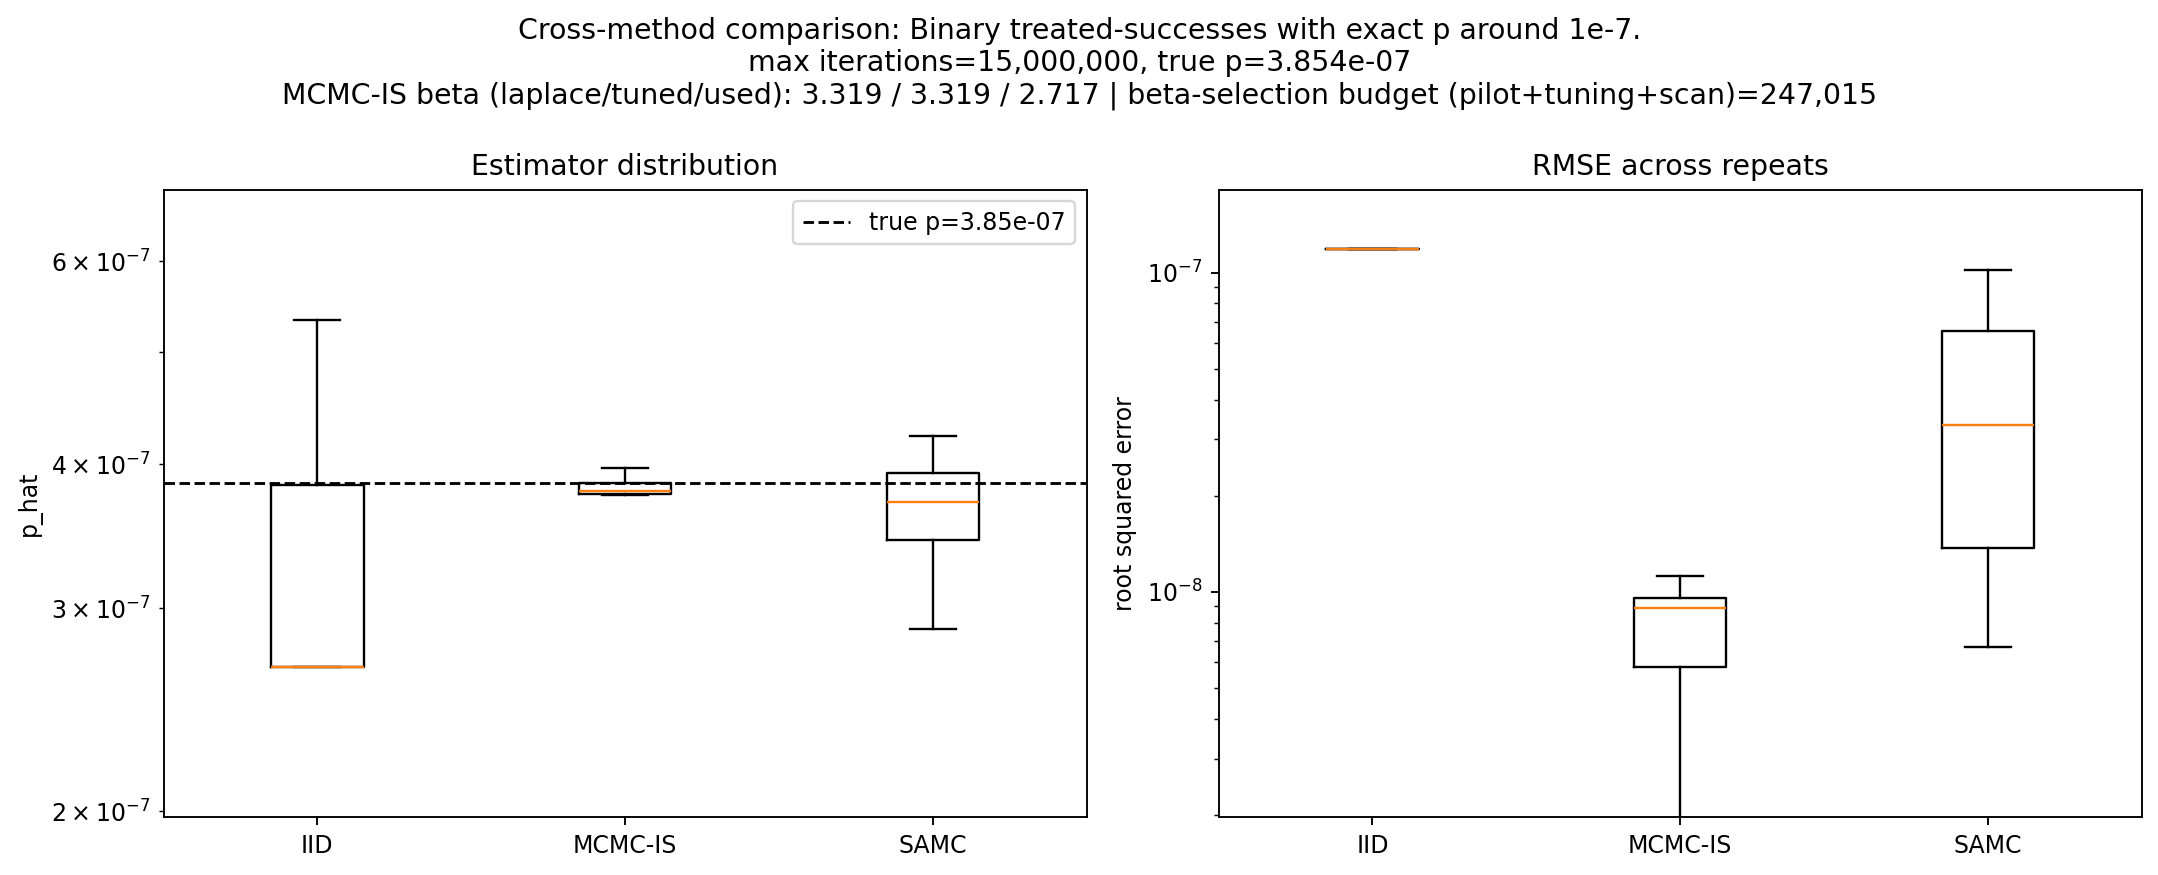

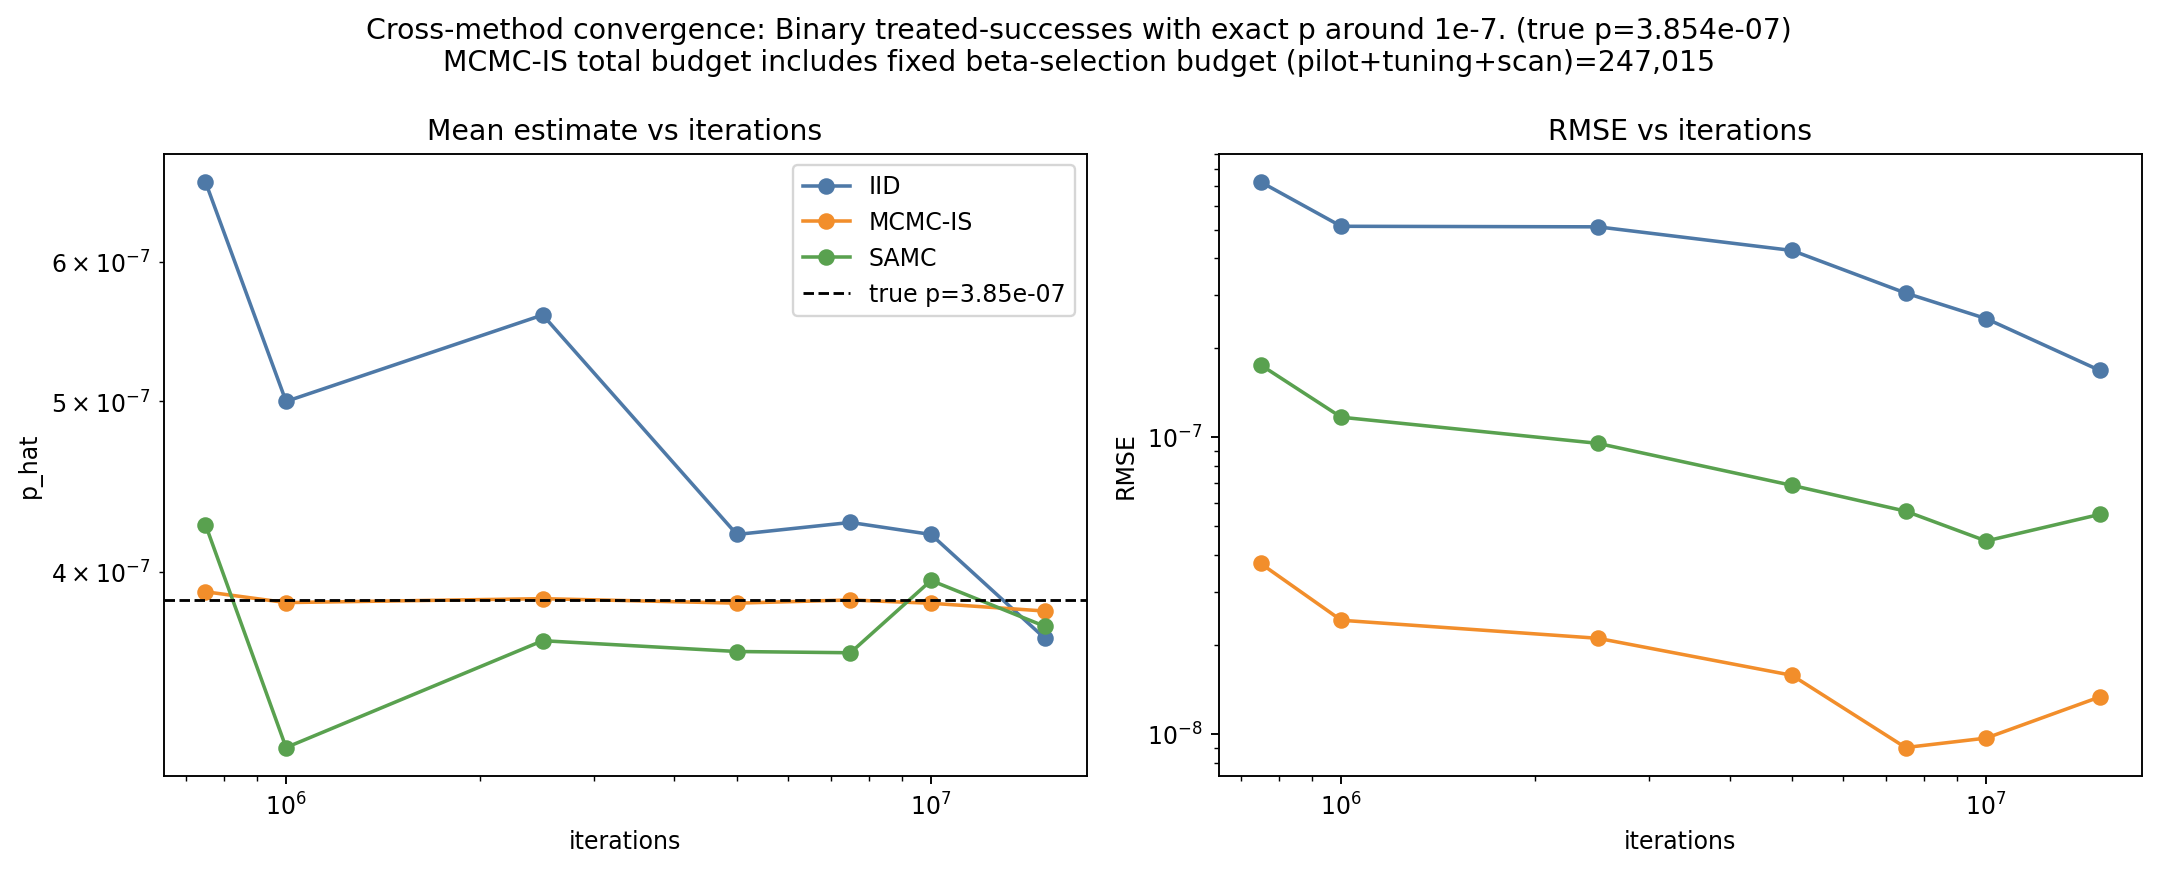

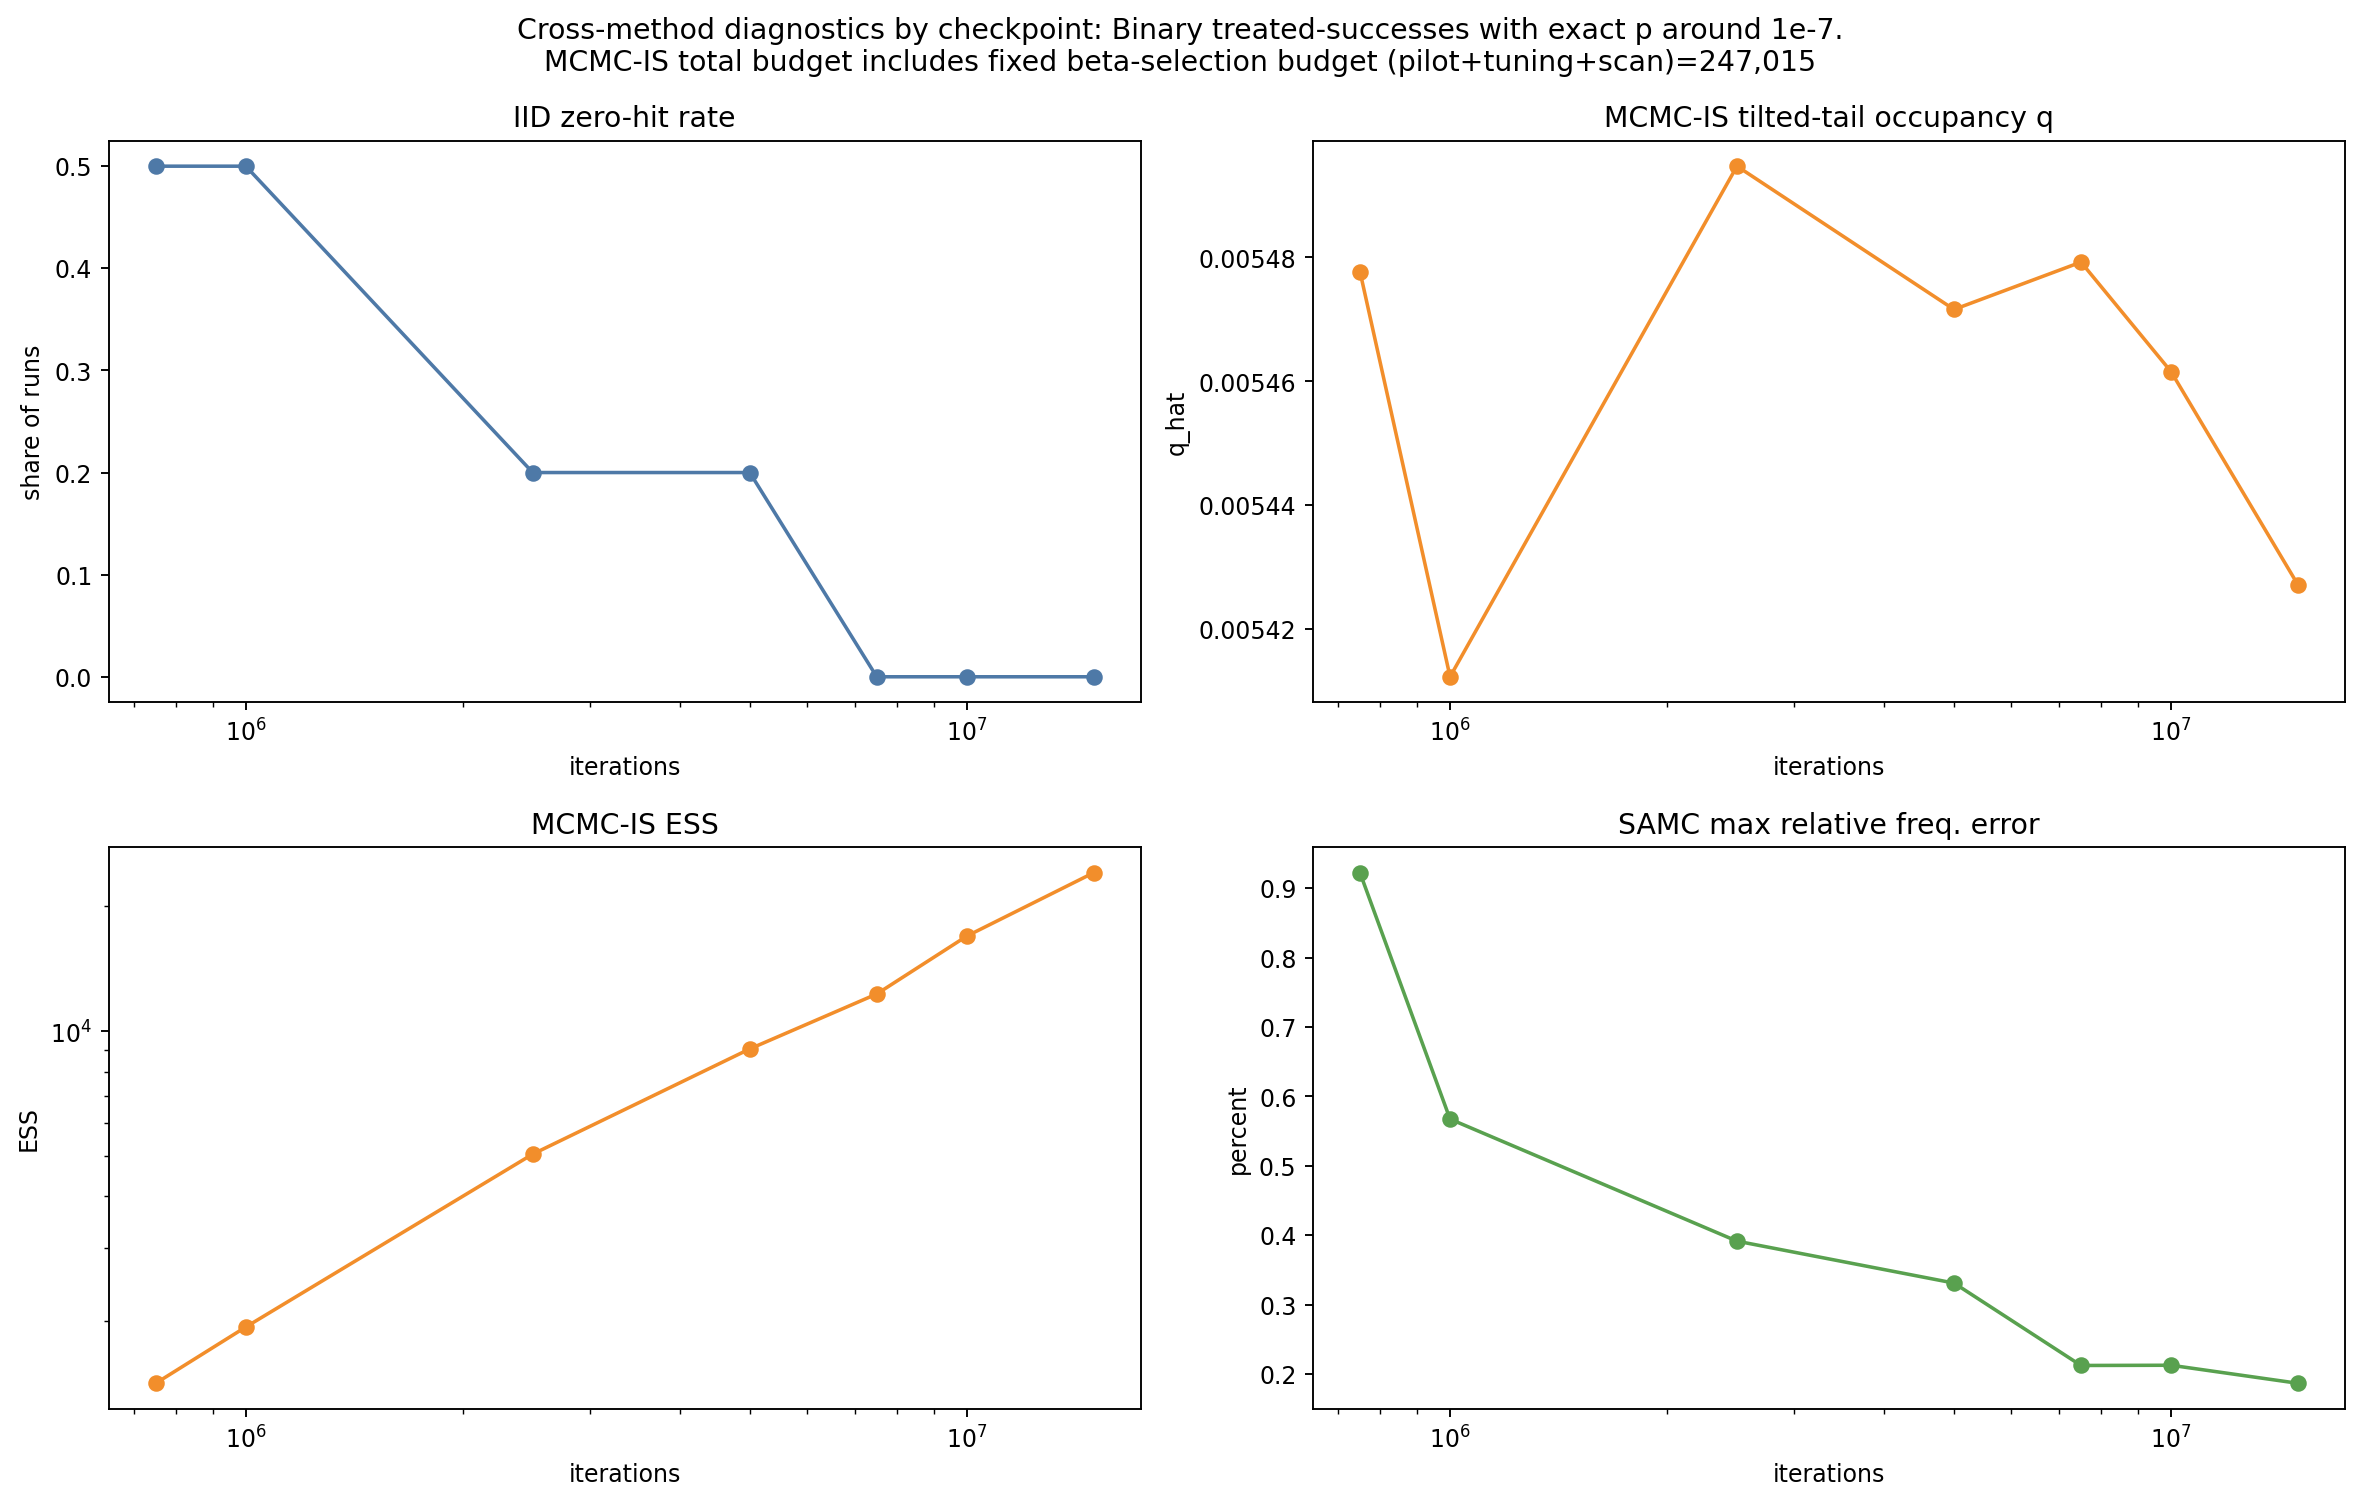

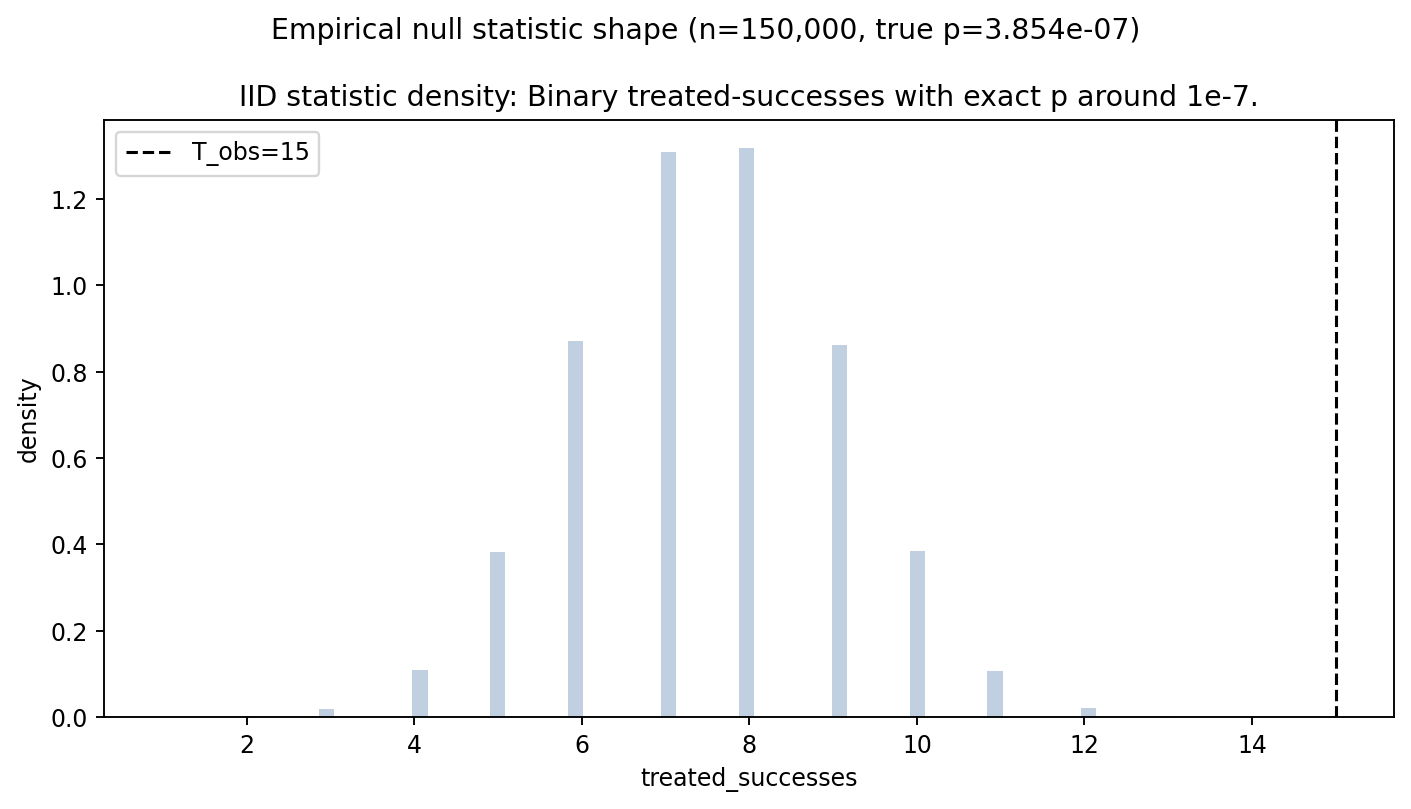


gwas_additive_score_n40


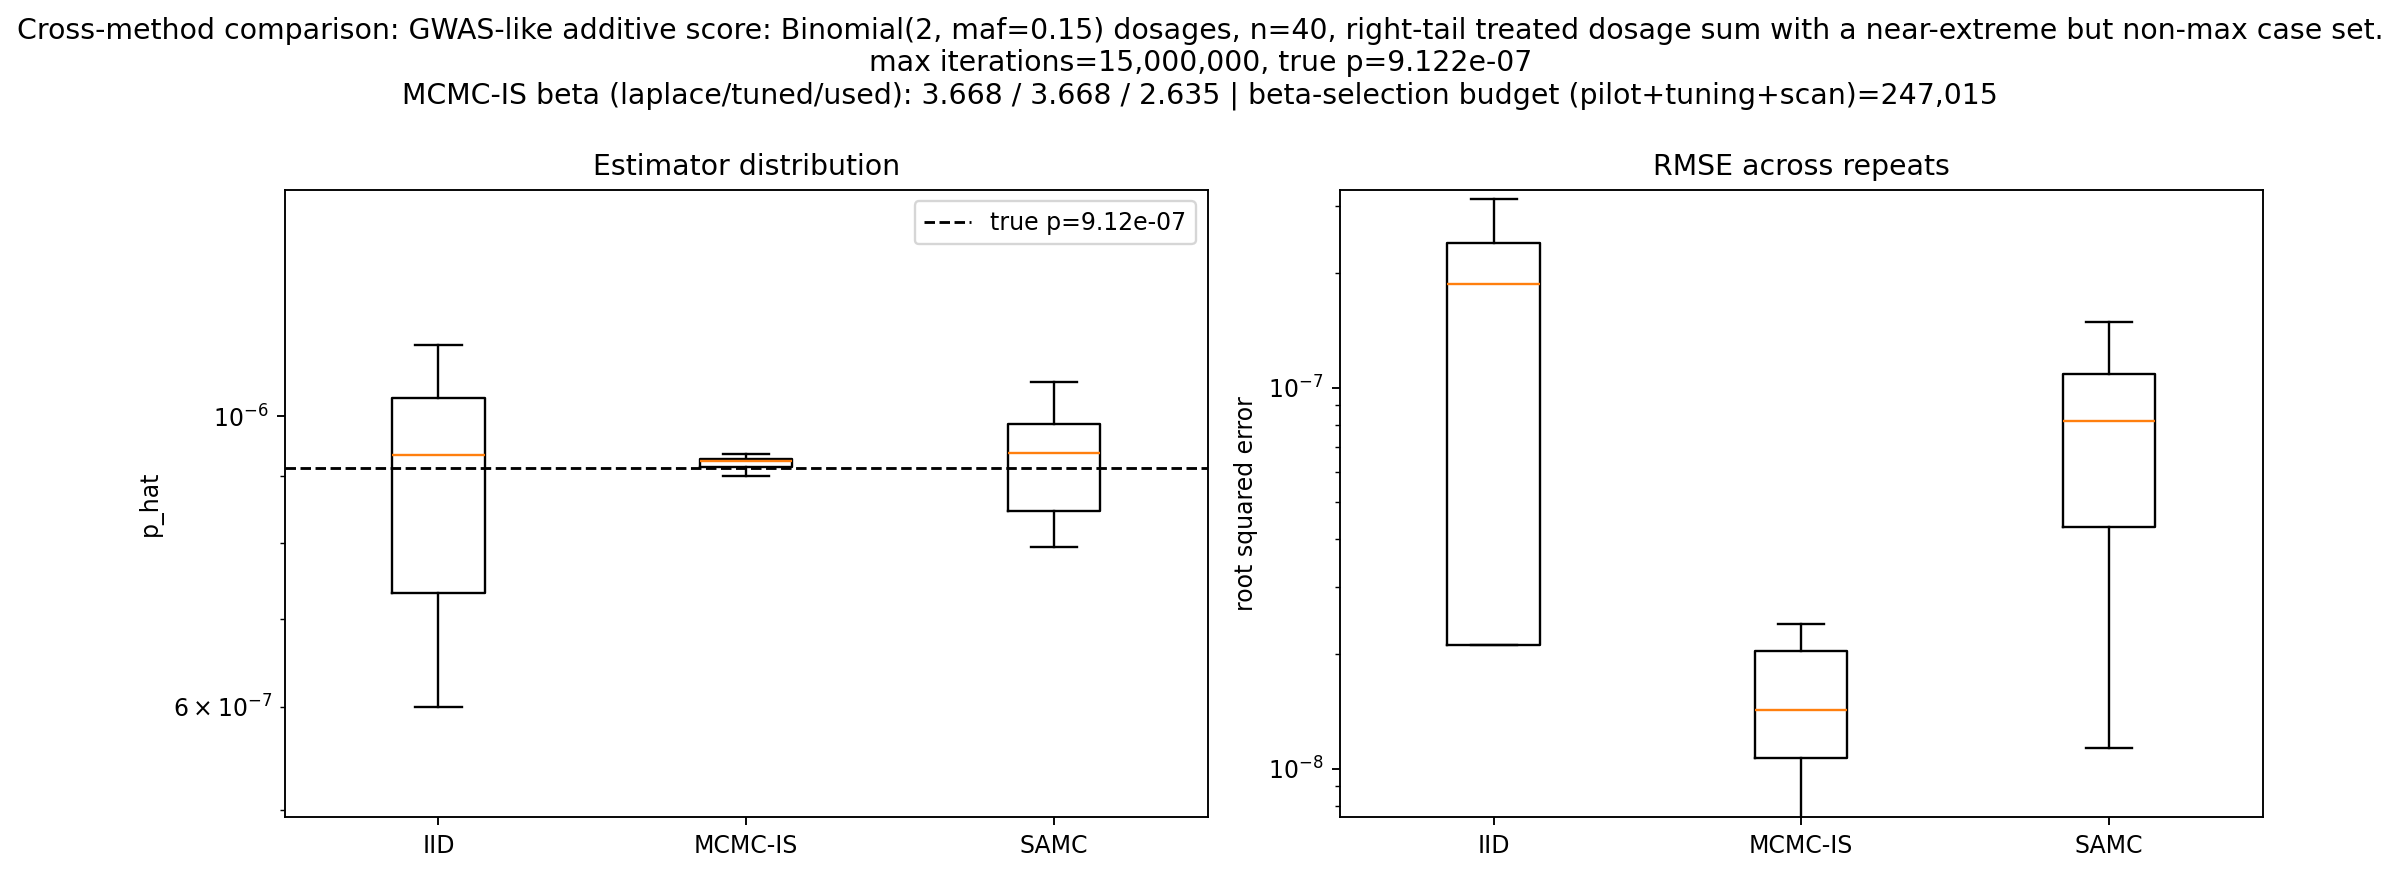

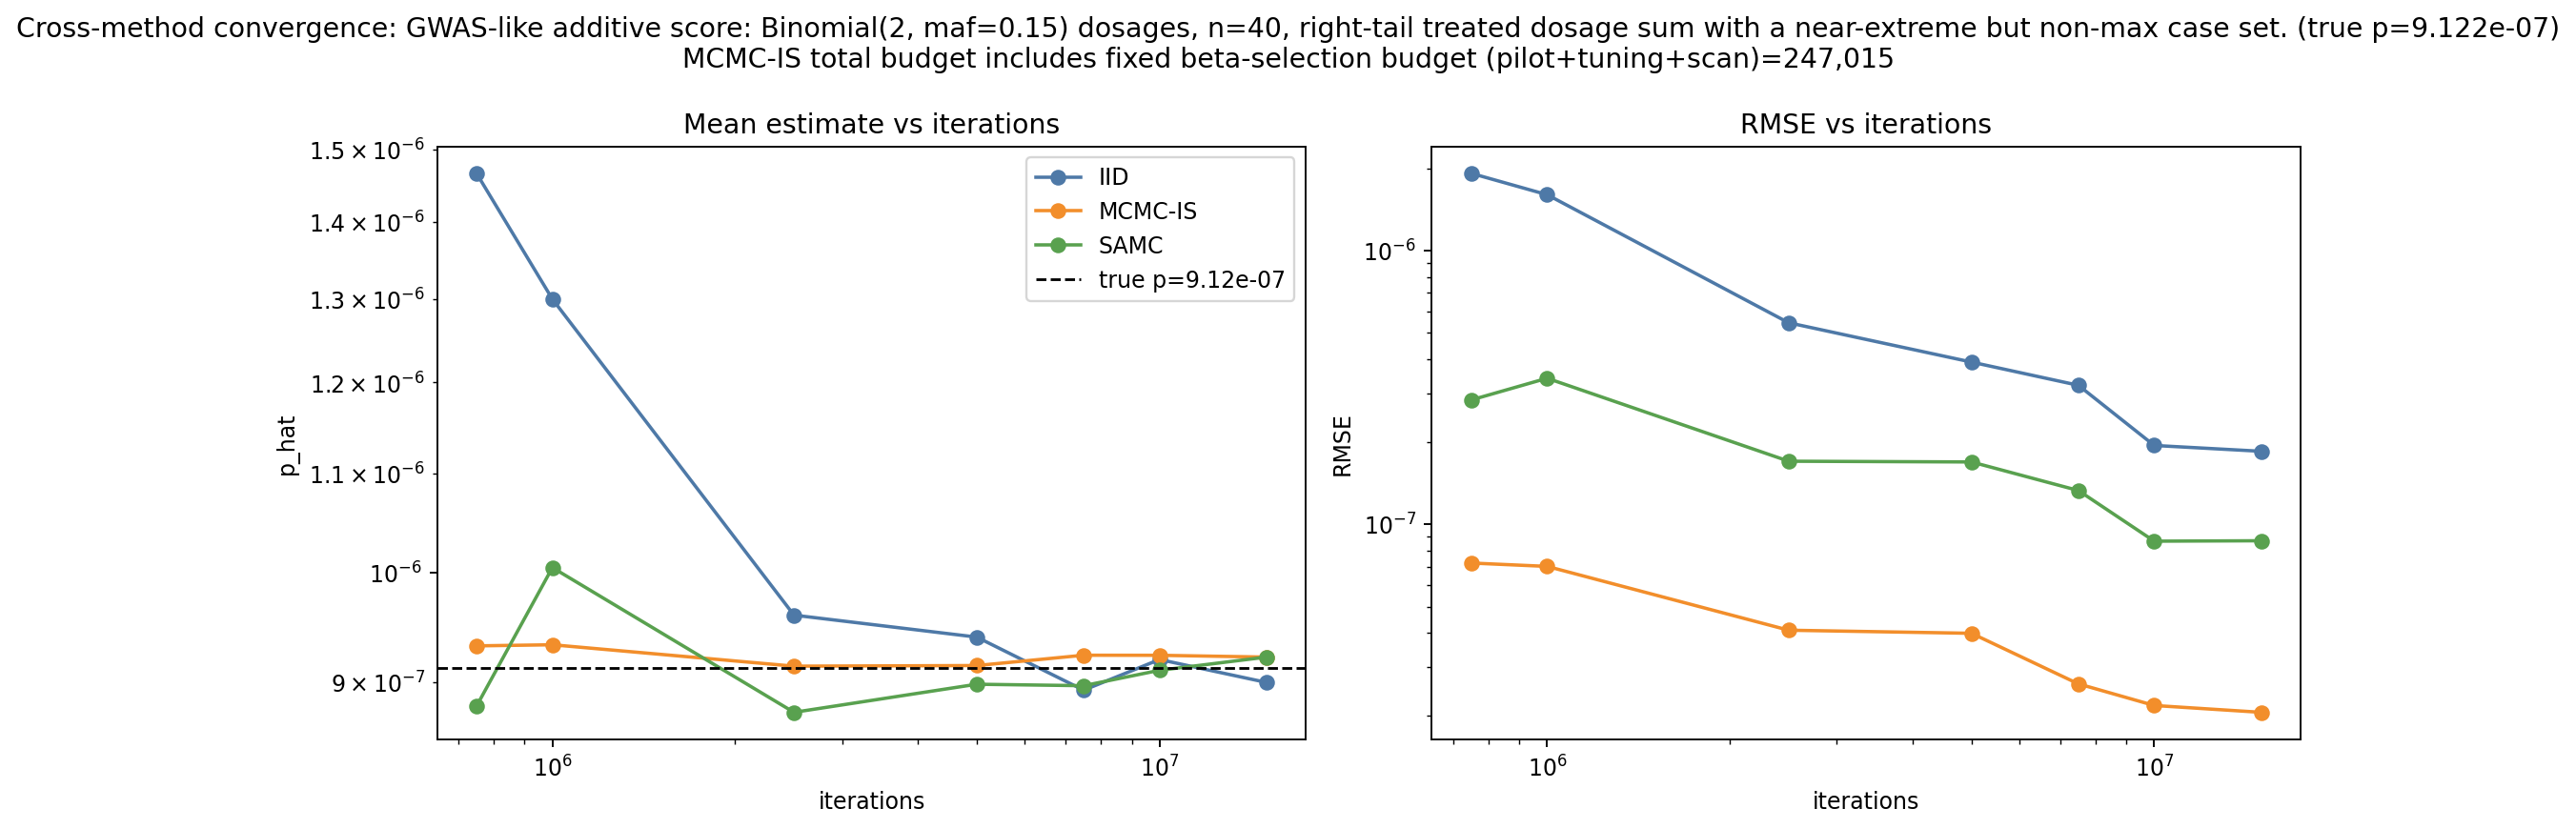

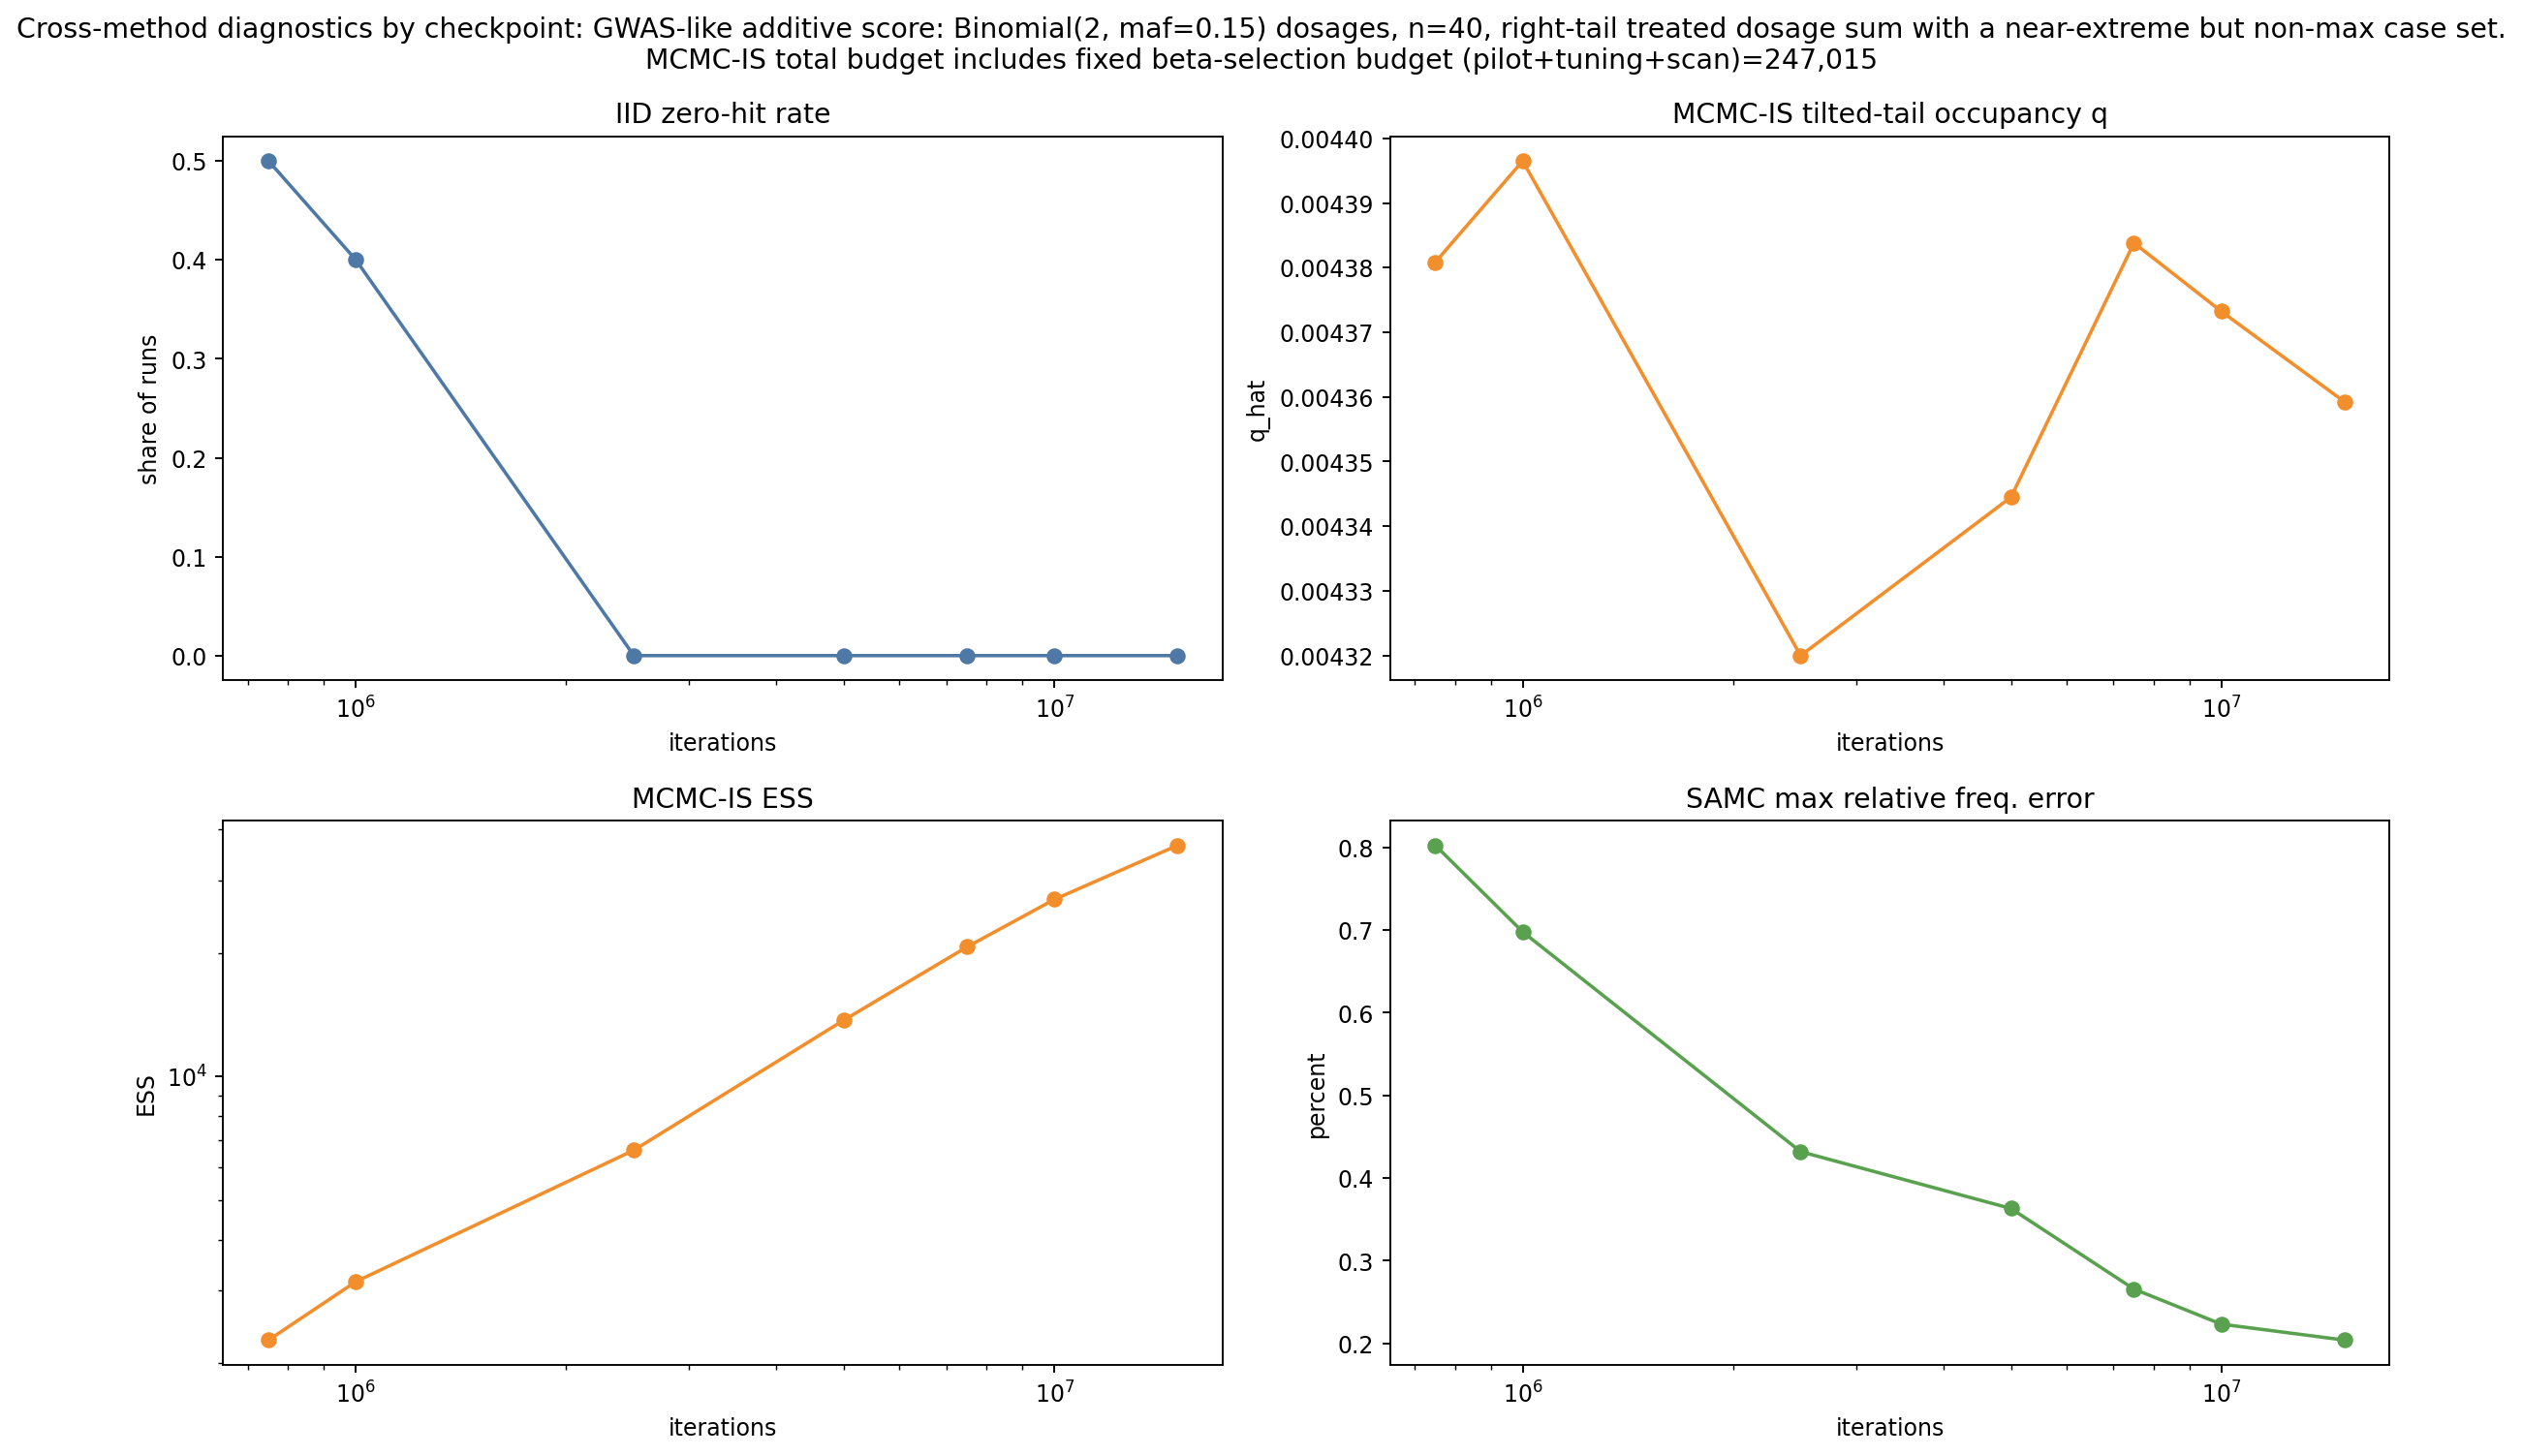

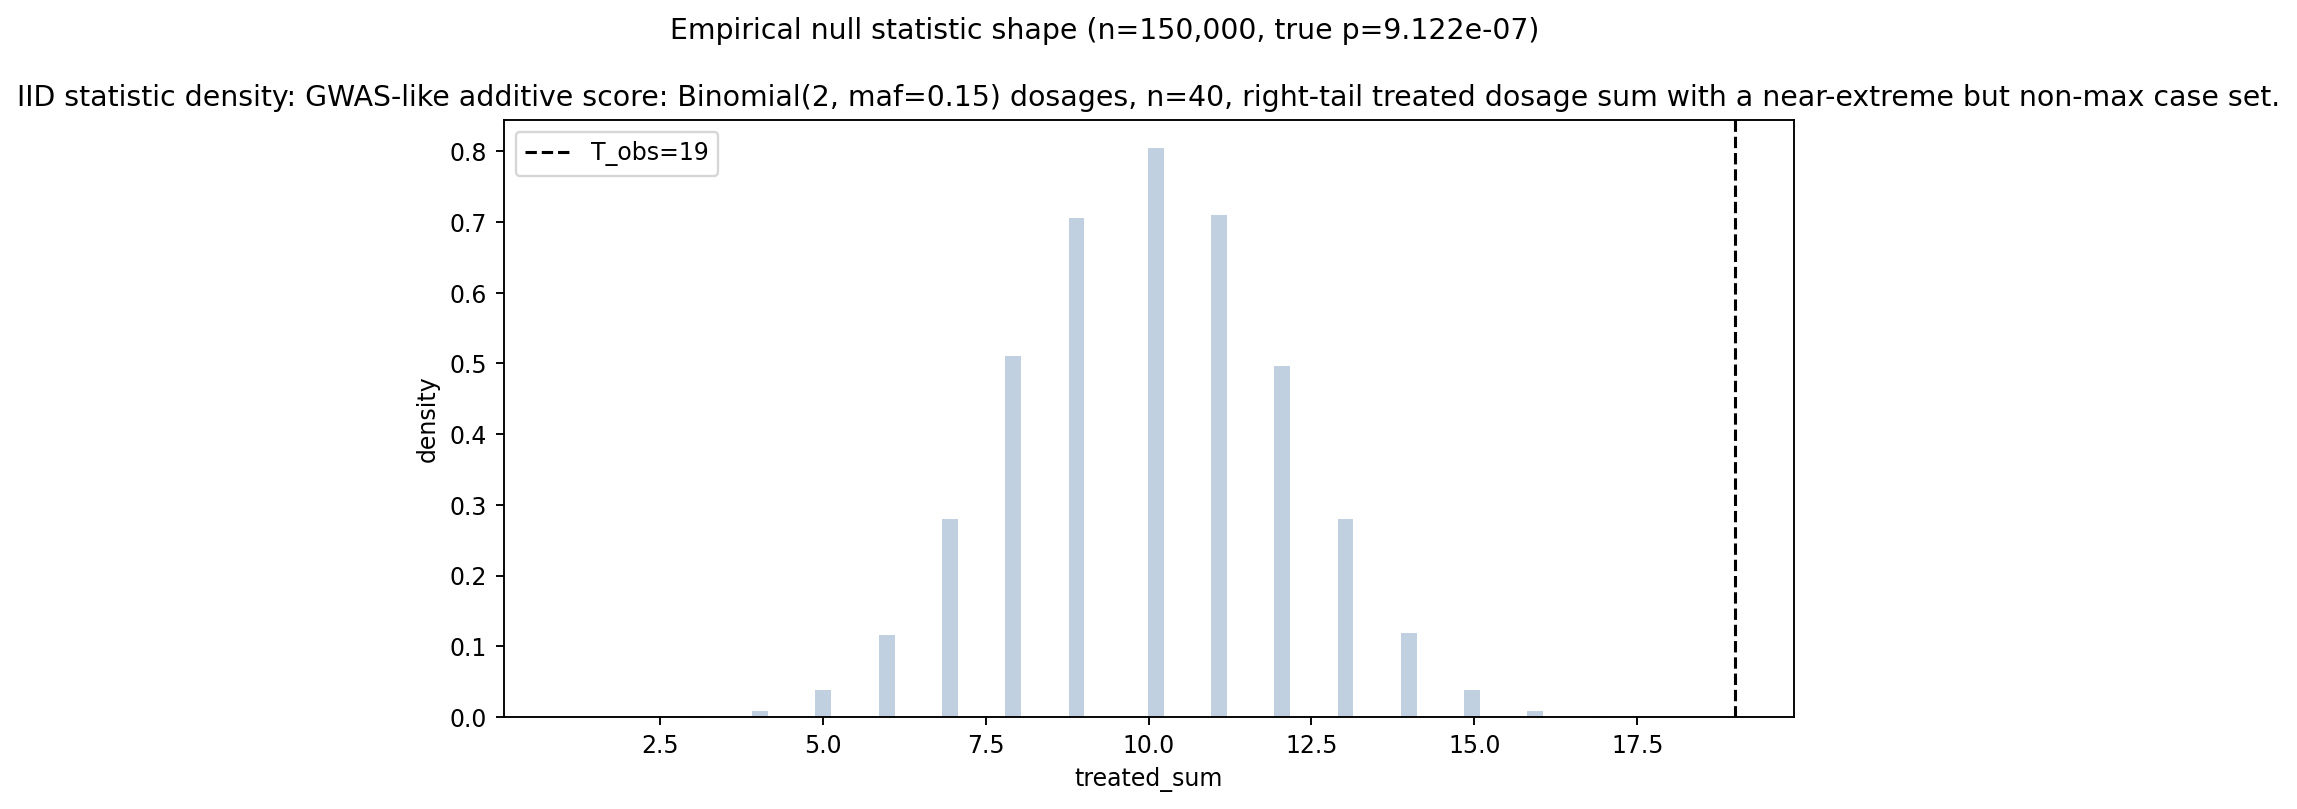


rank_sum_dp_n40


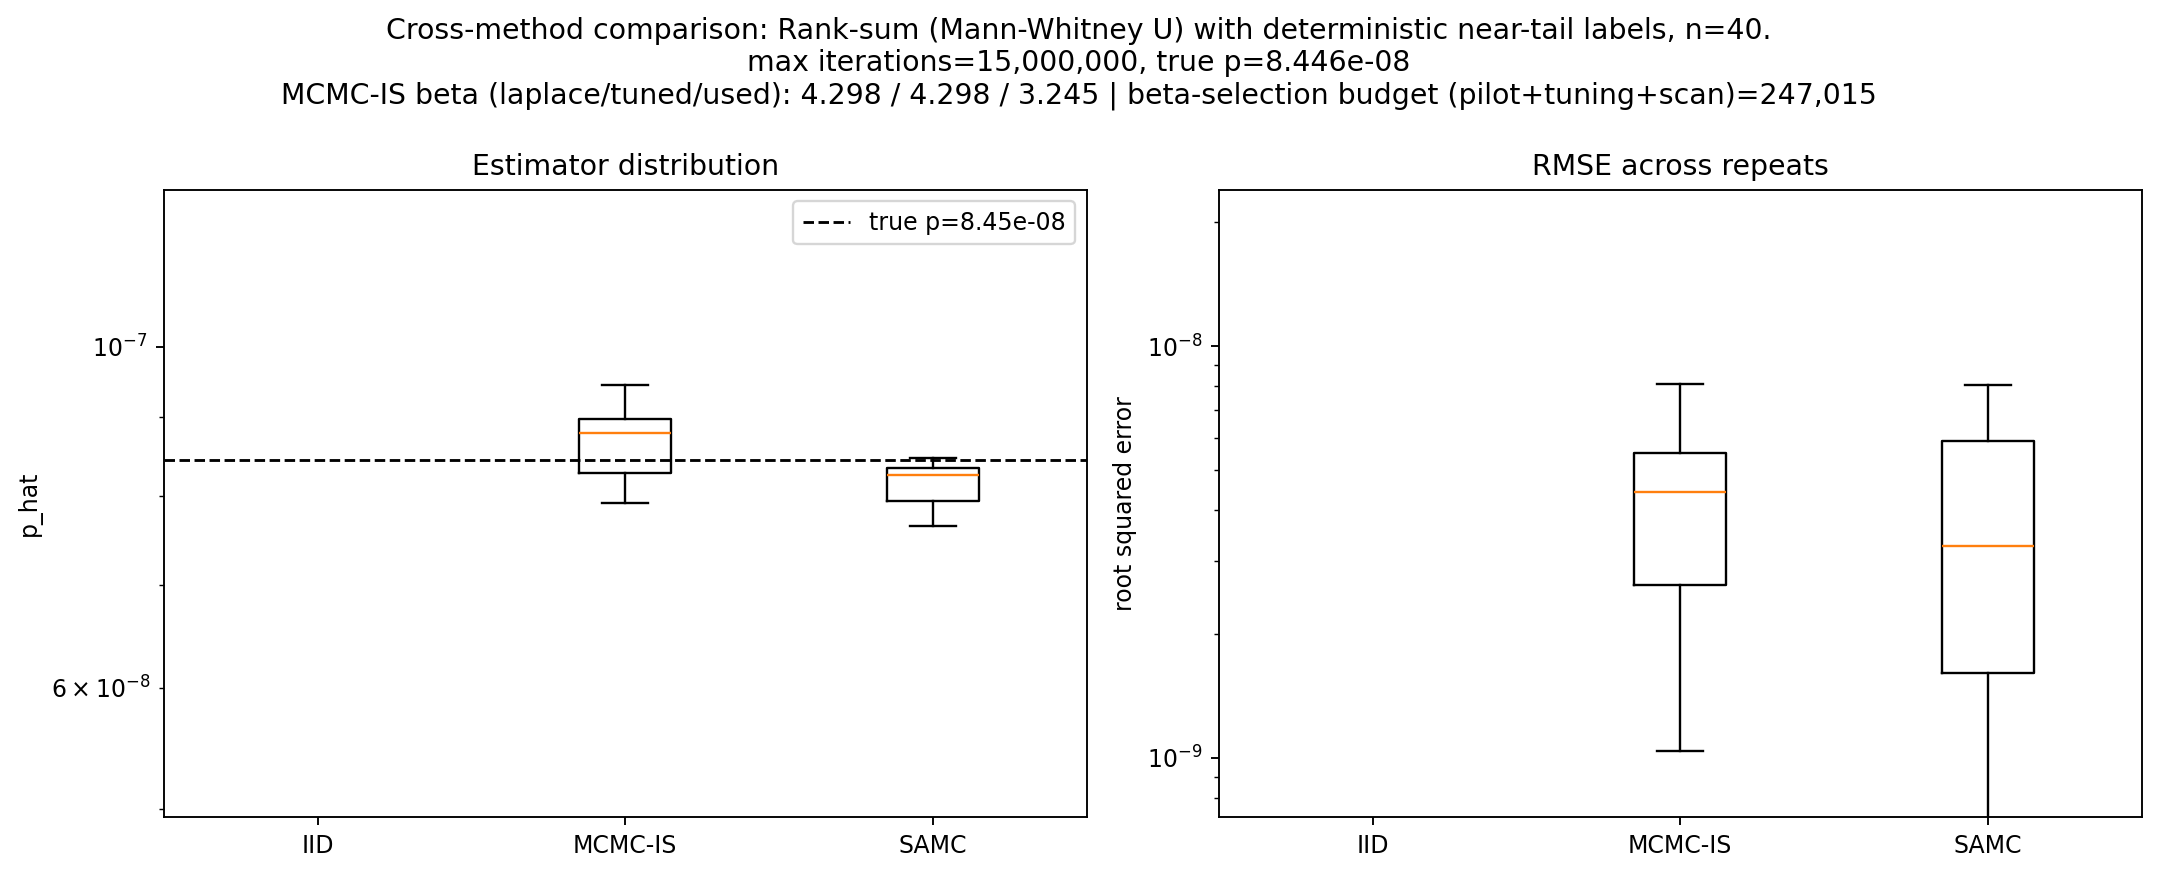

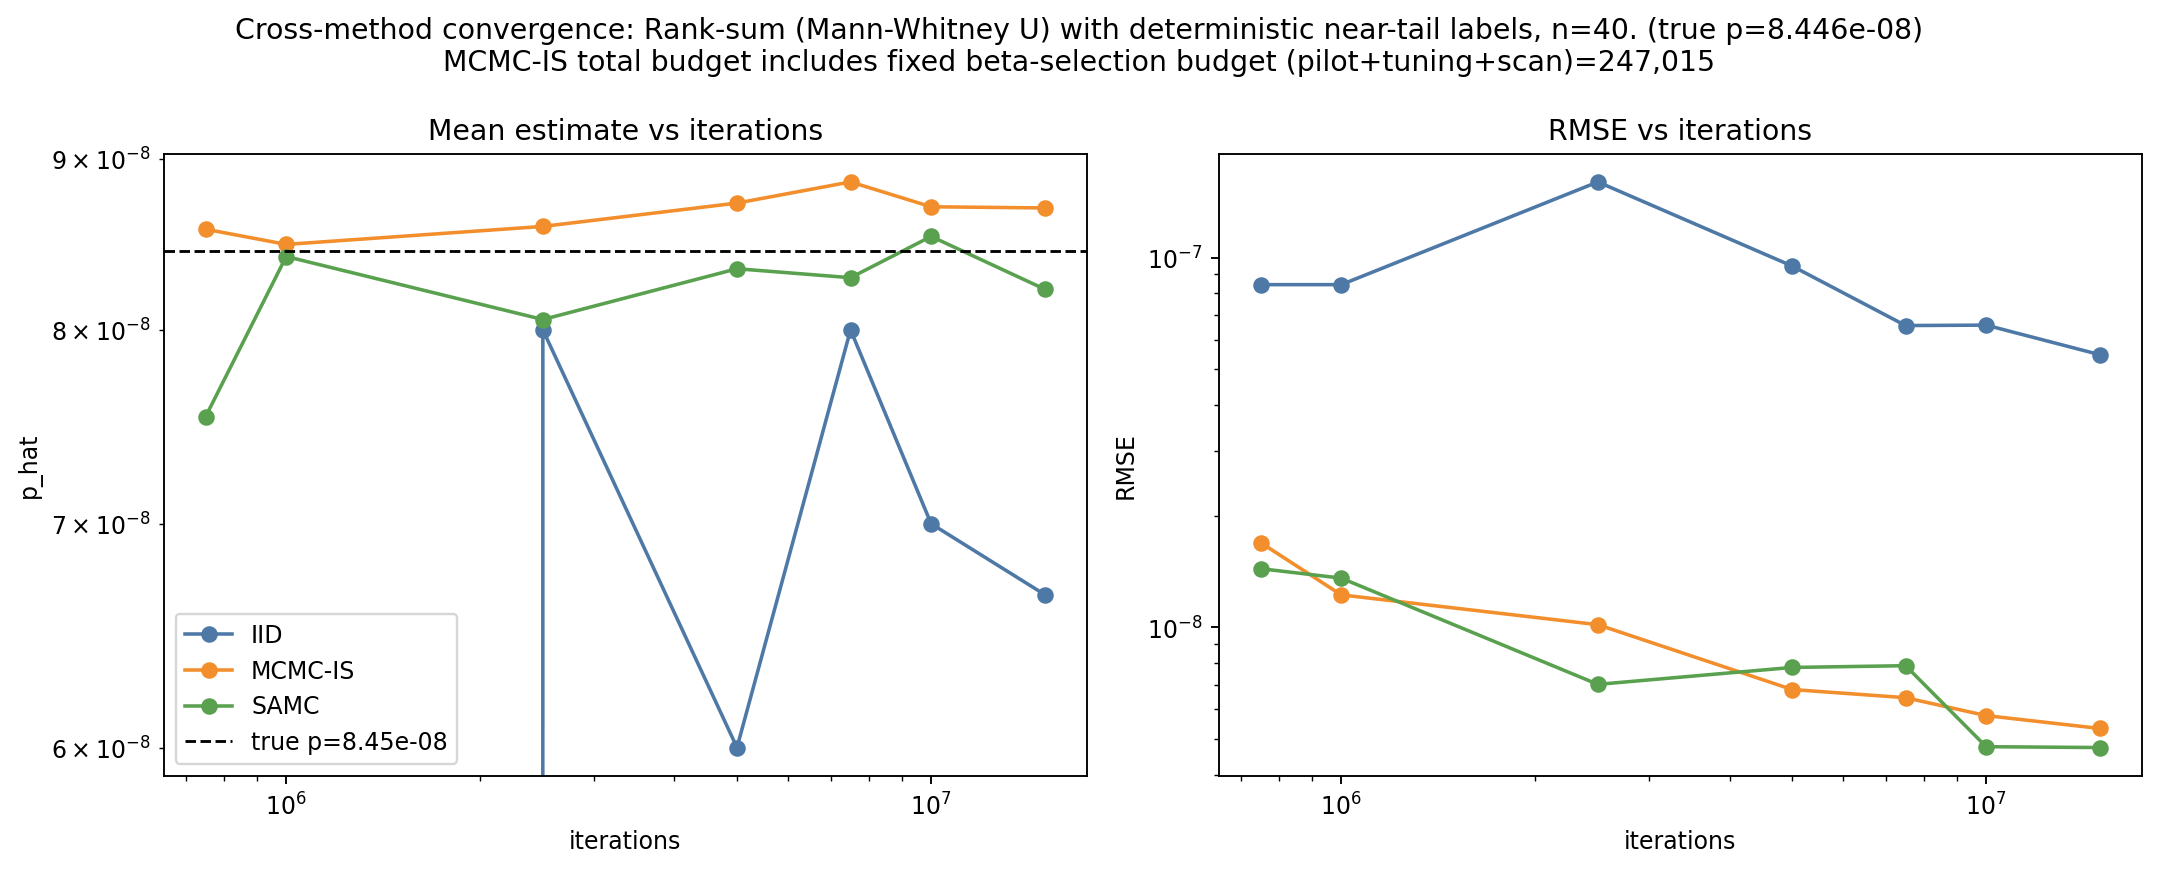

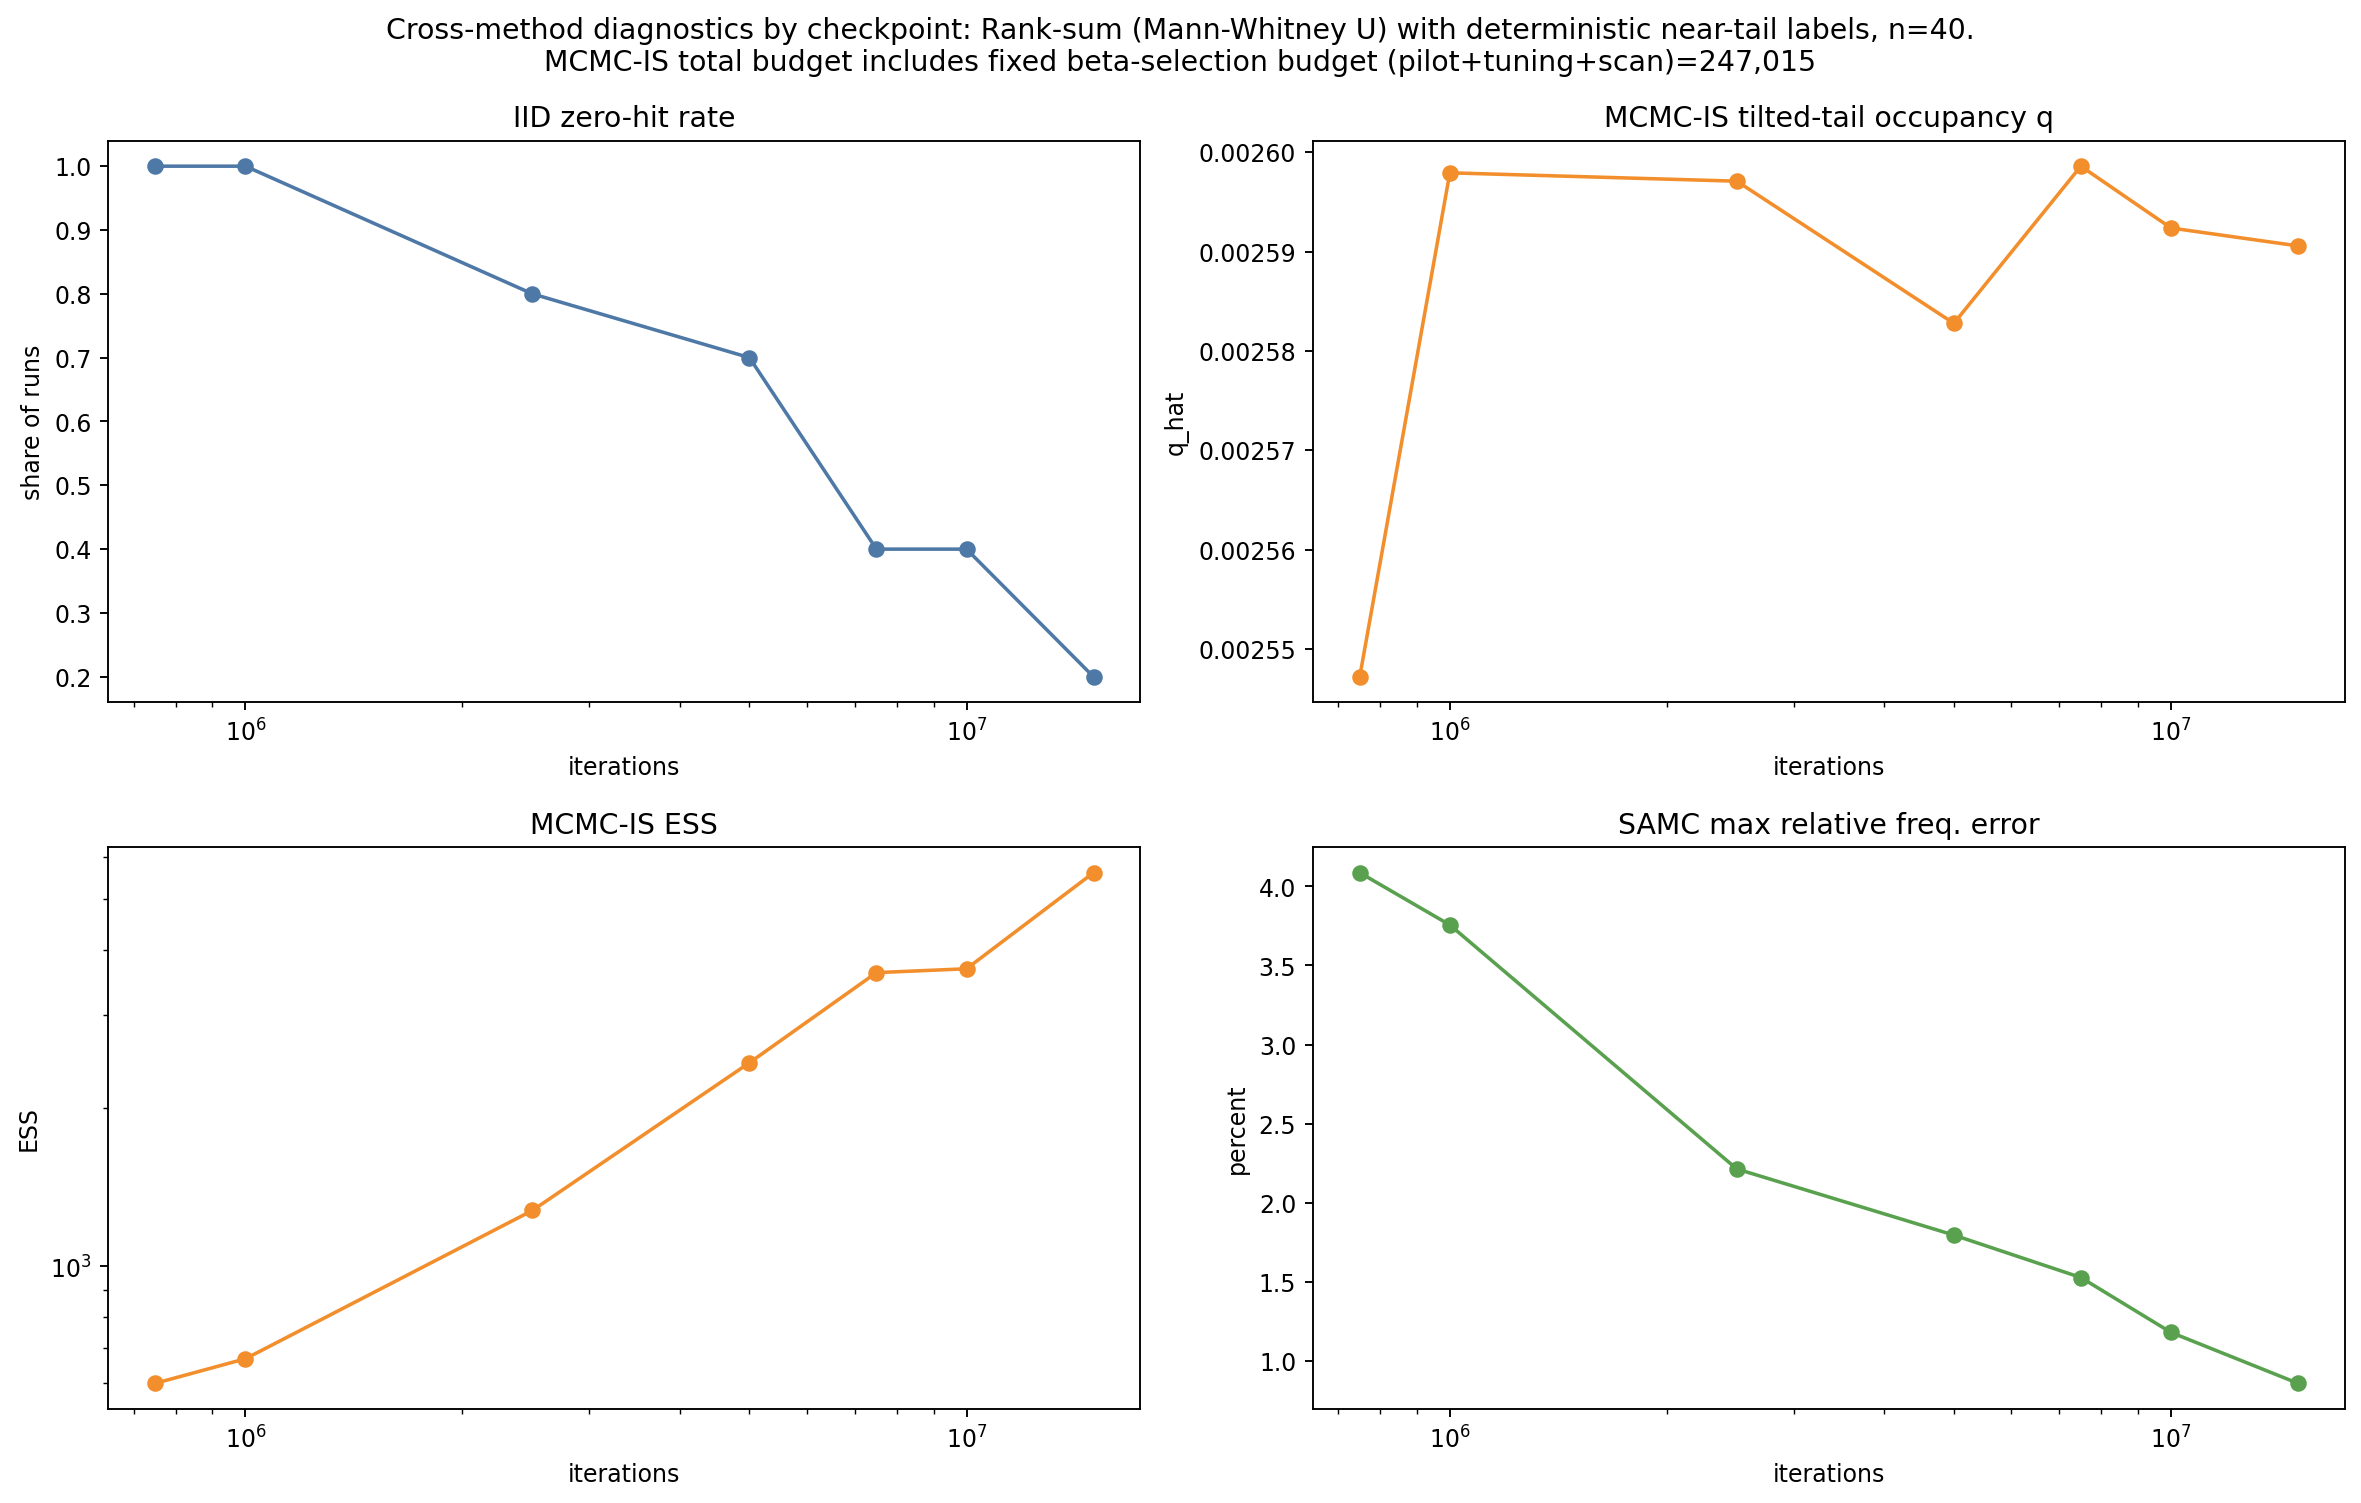

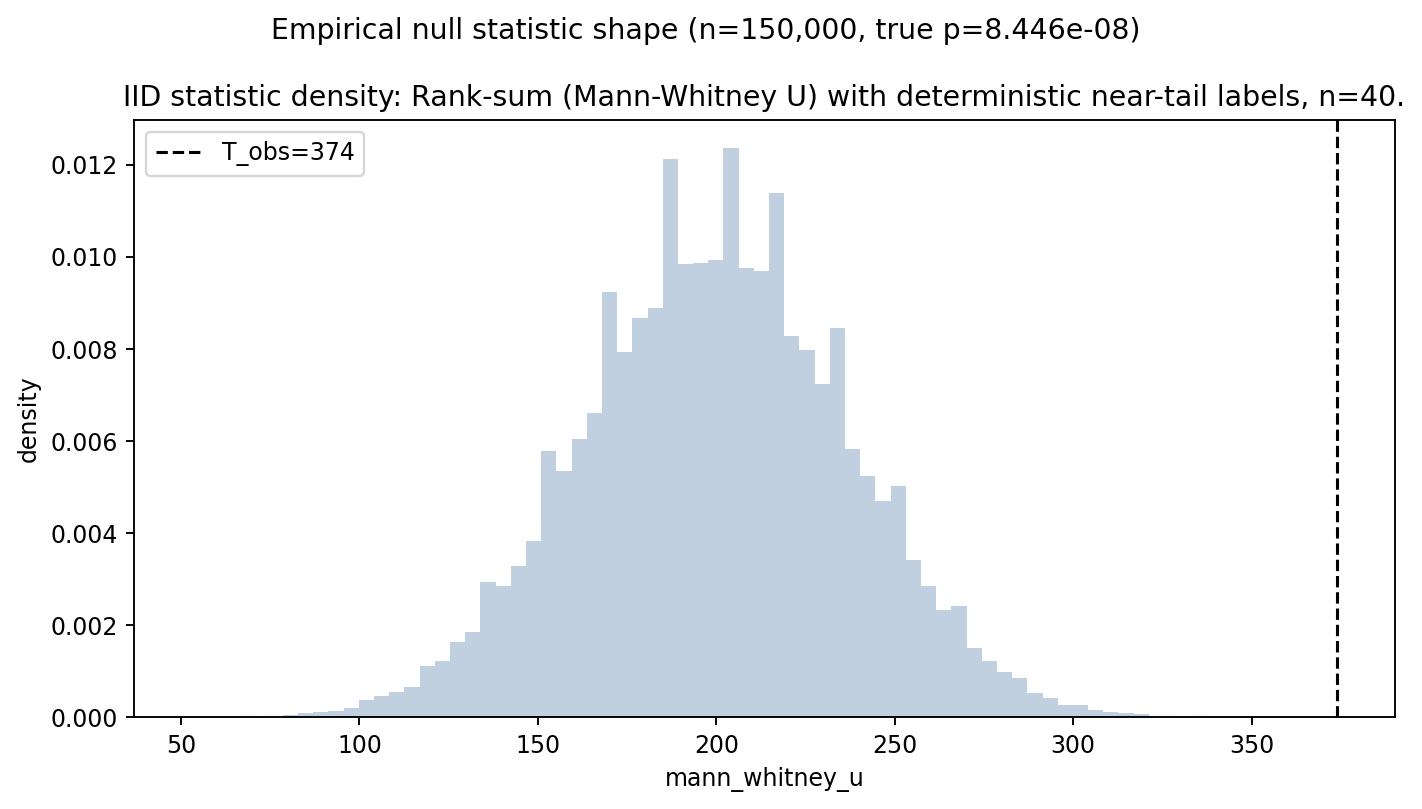


linear_stat_dp_n40


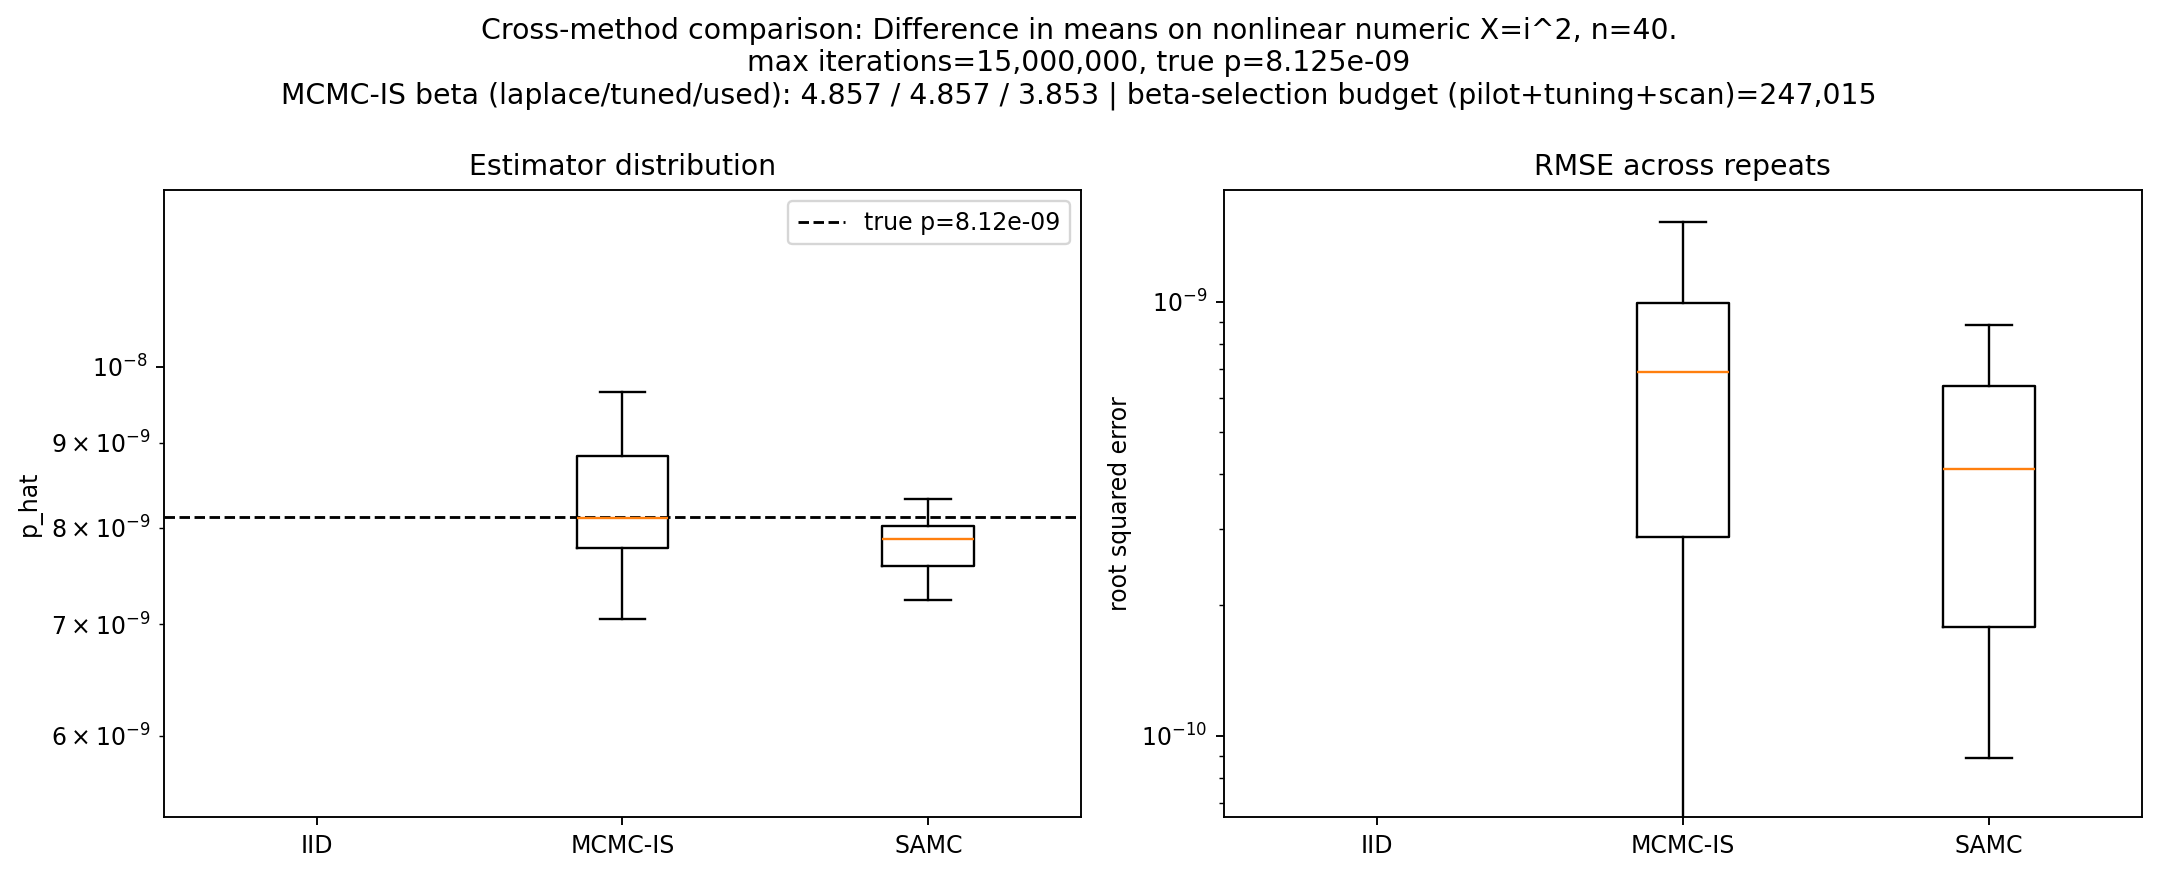

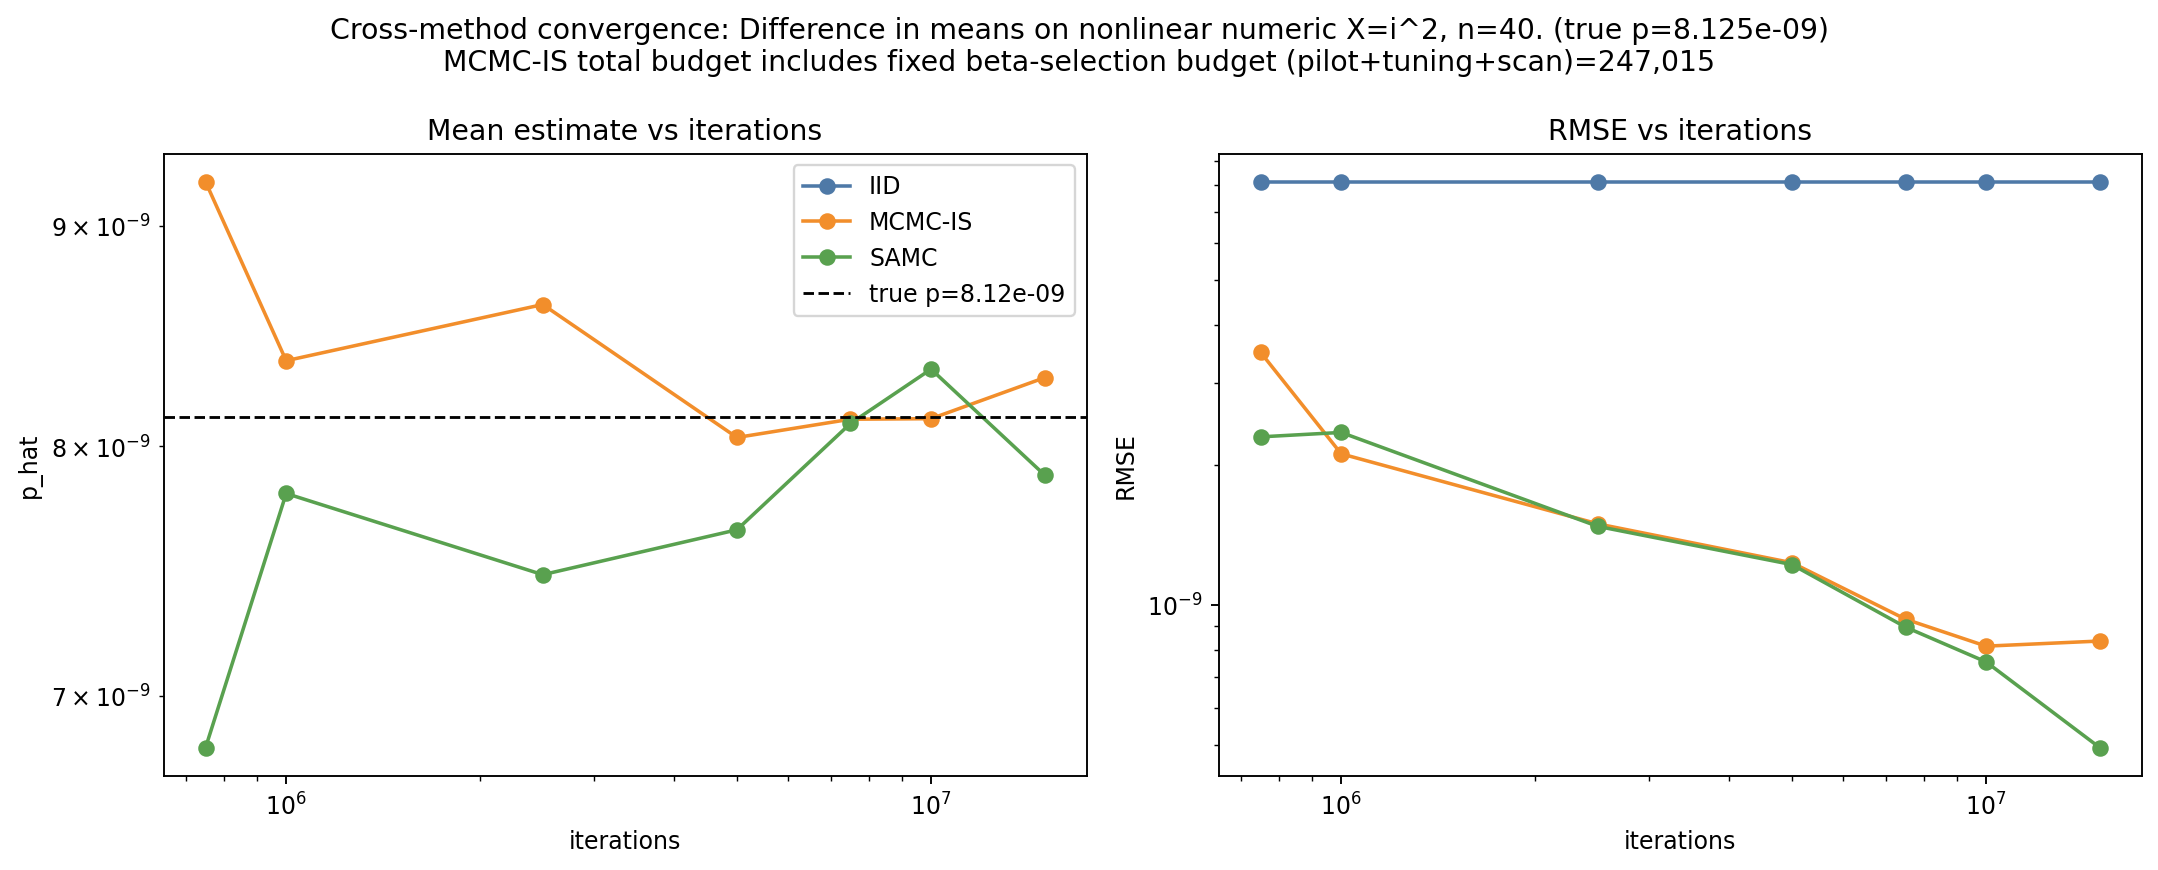

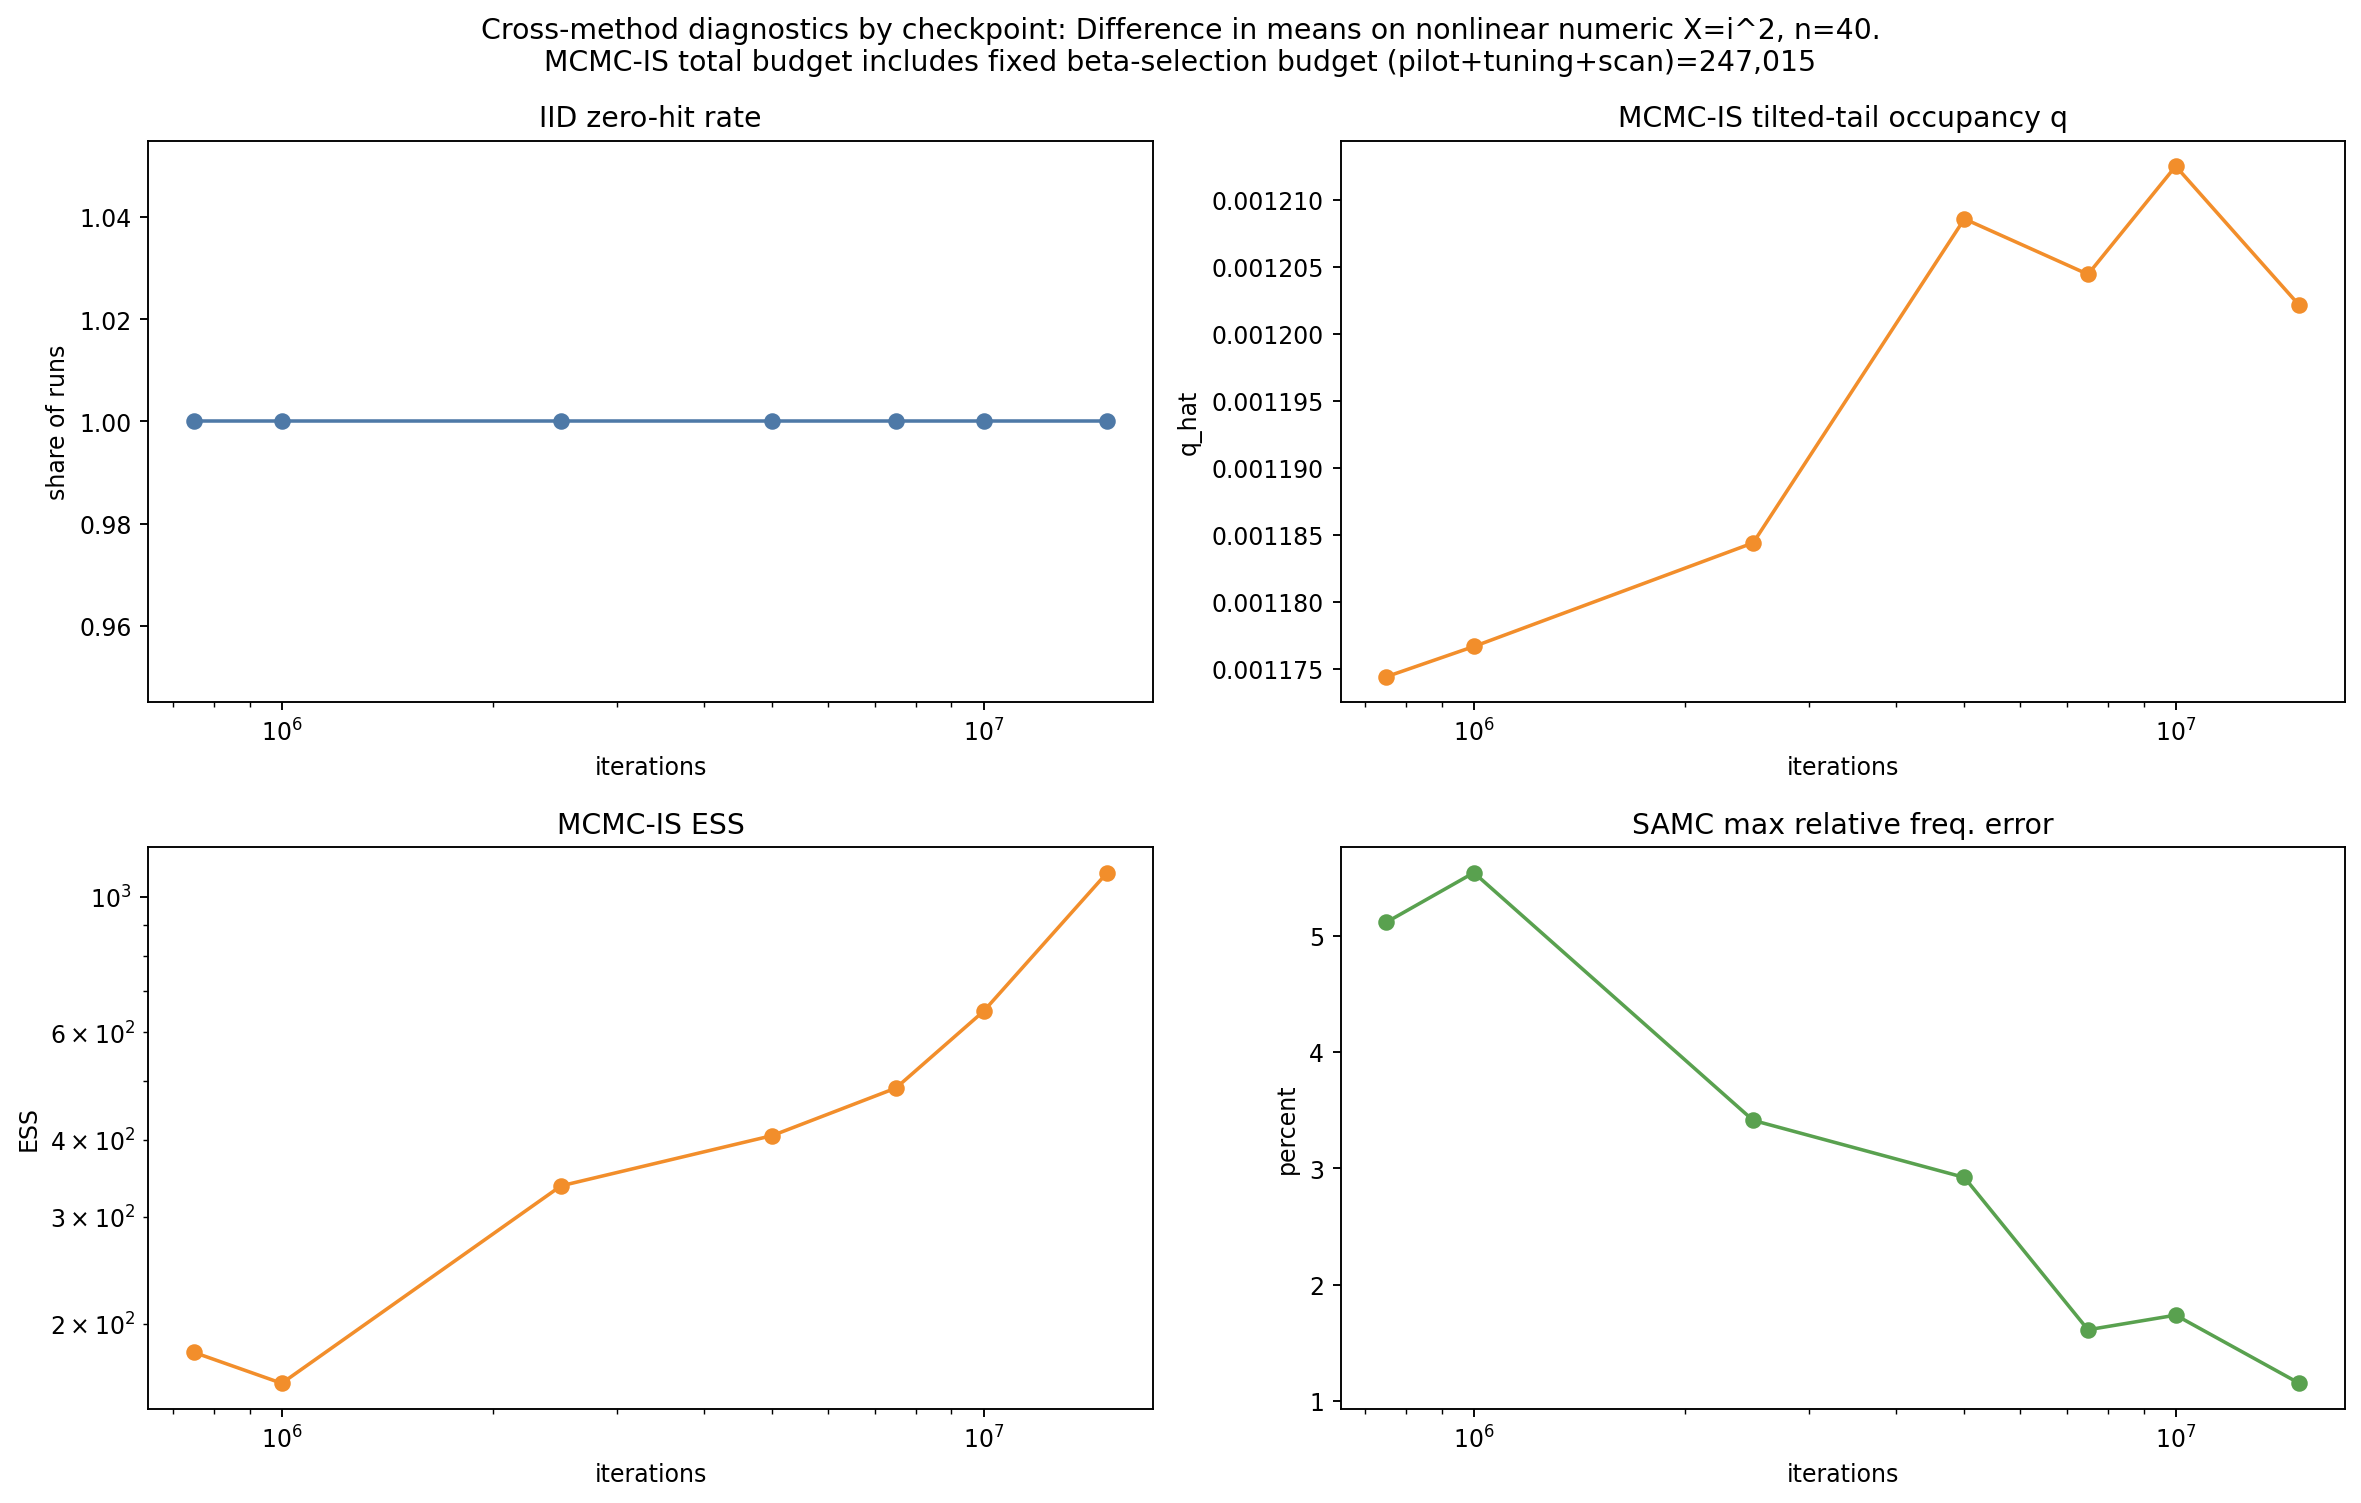

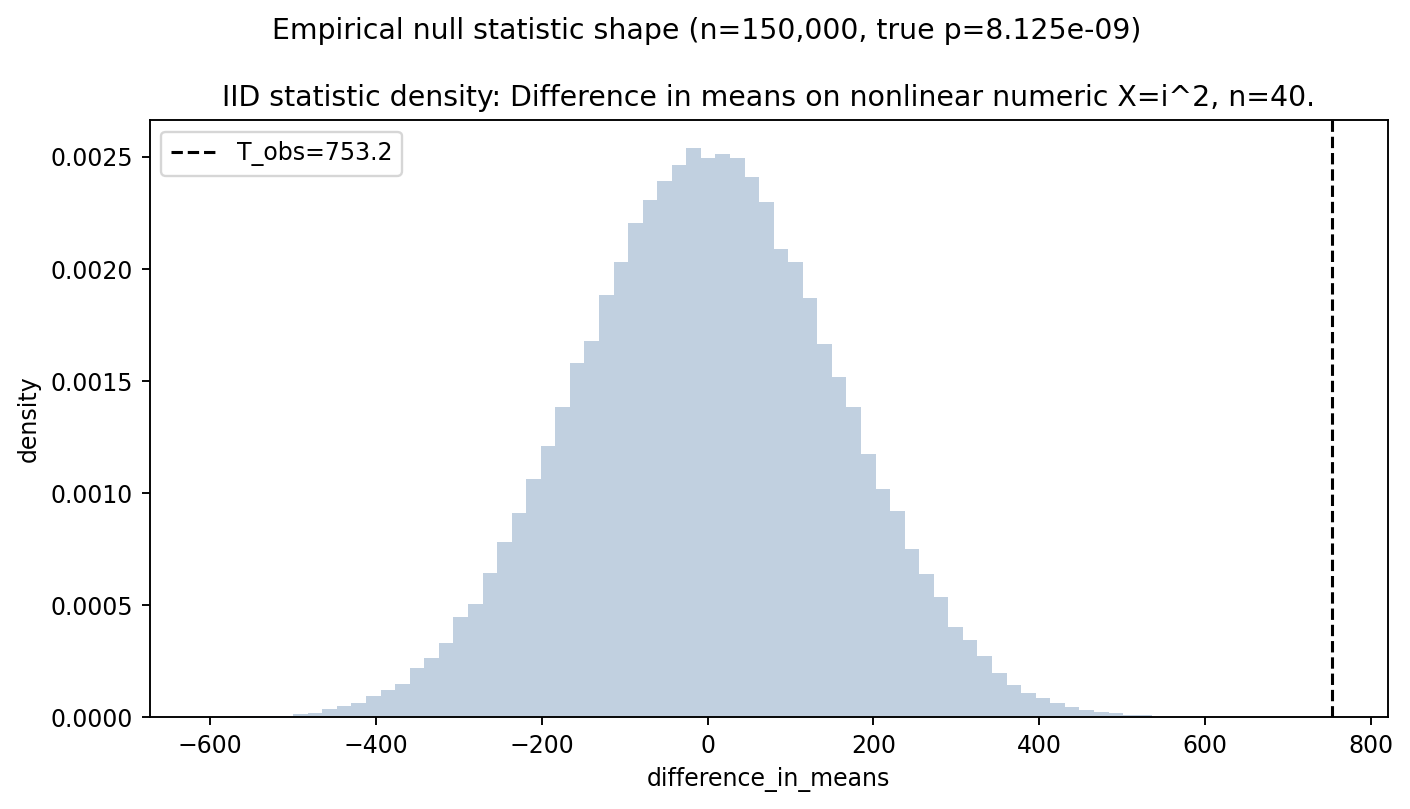


bruteforce_welch_nonextreme_n22


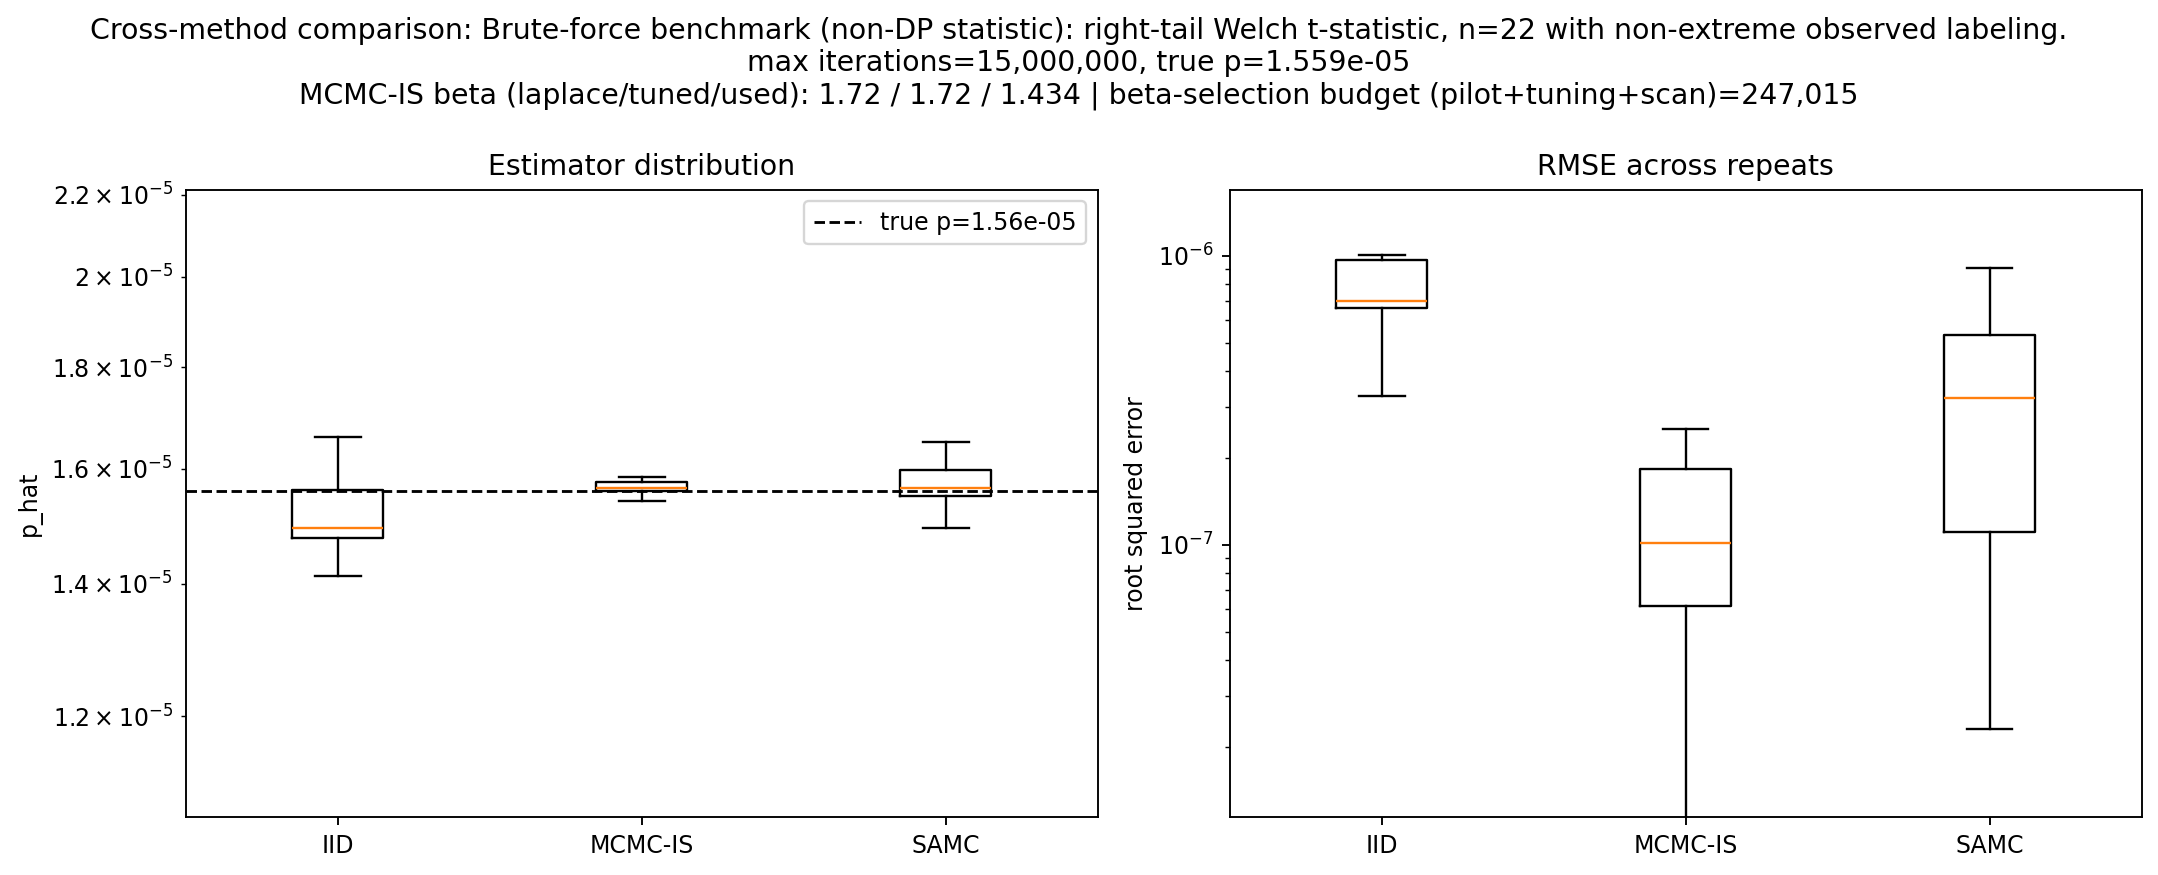

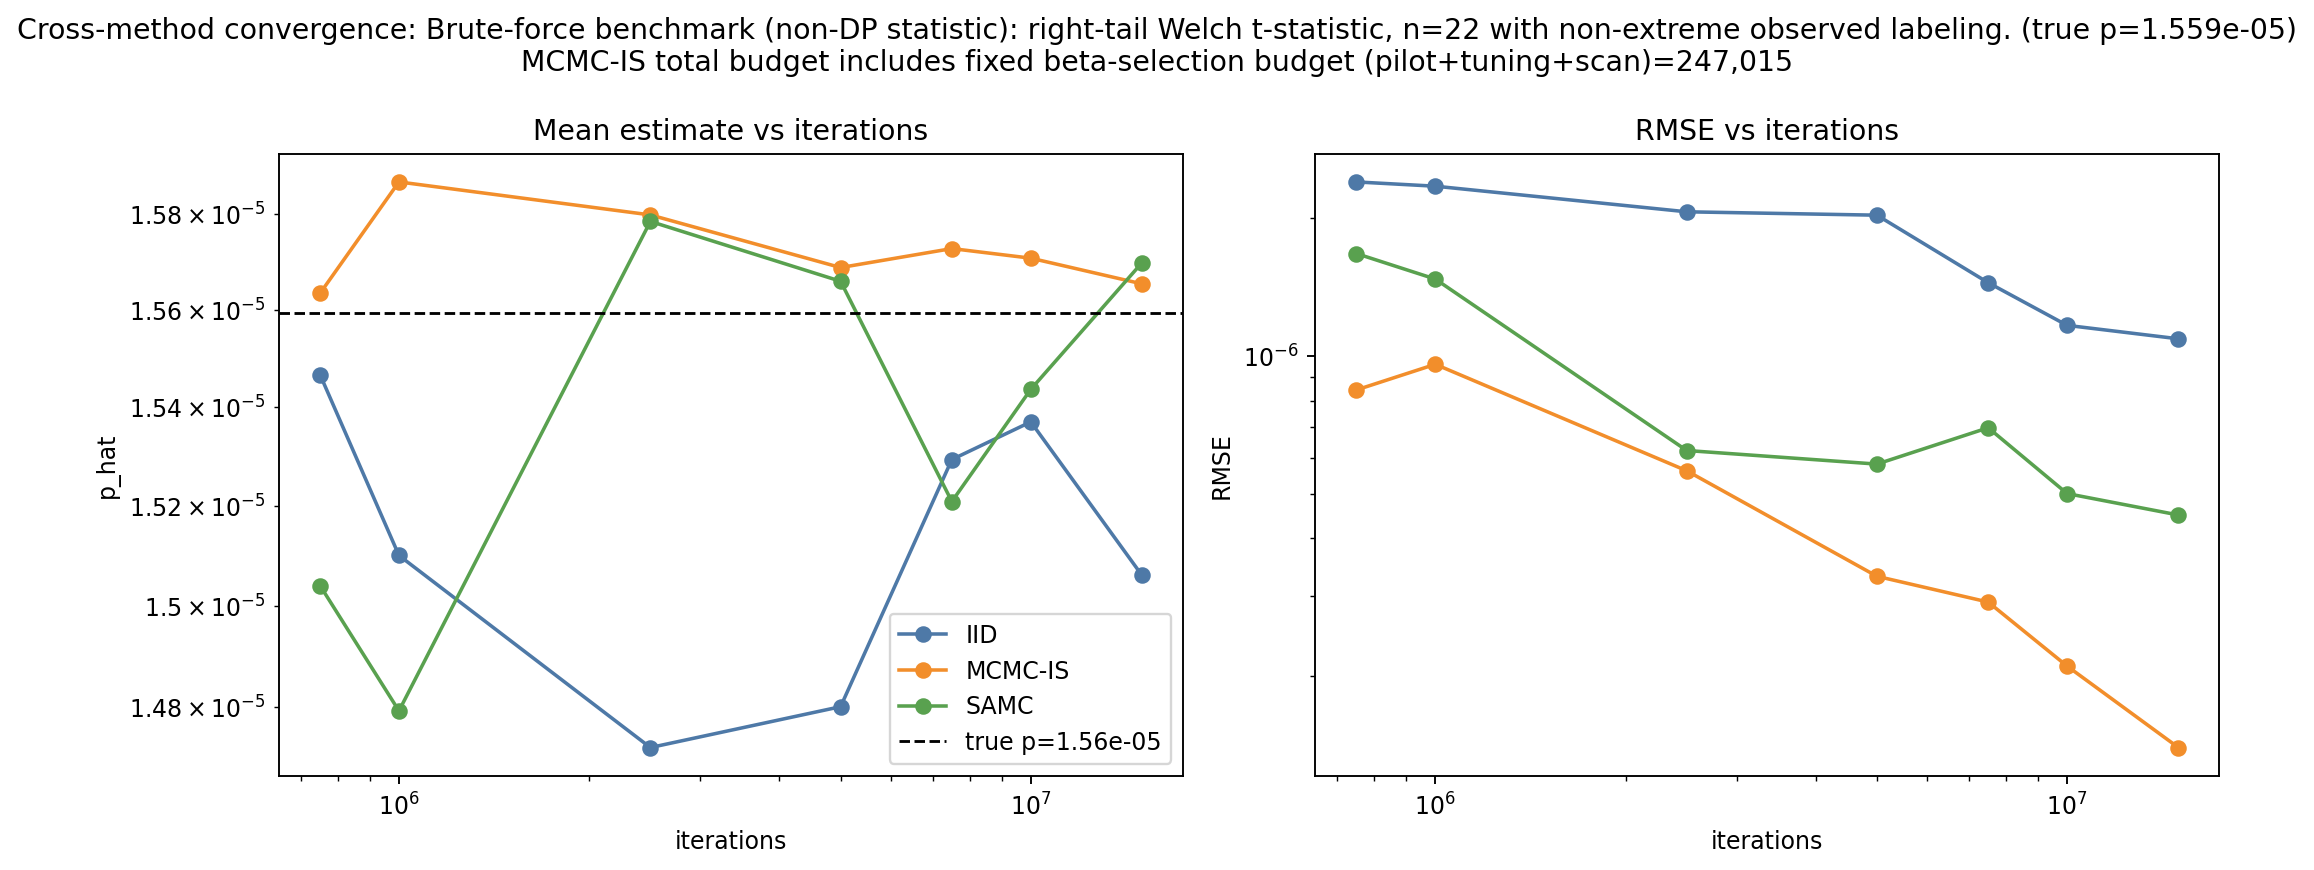

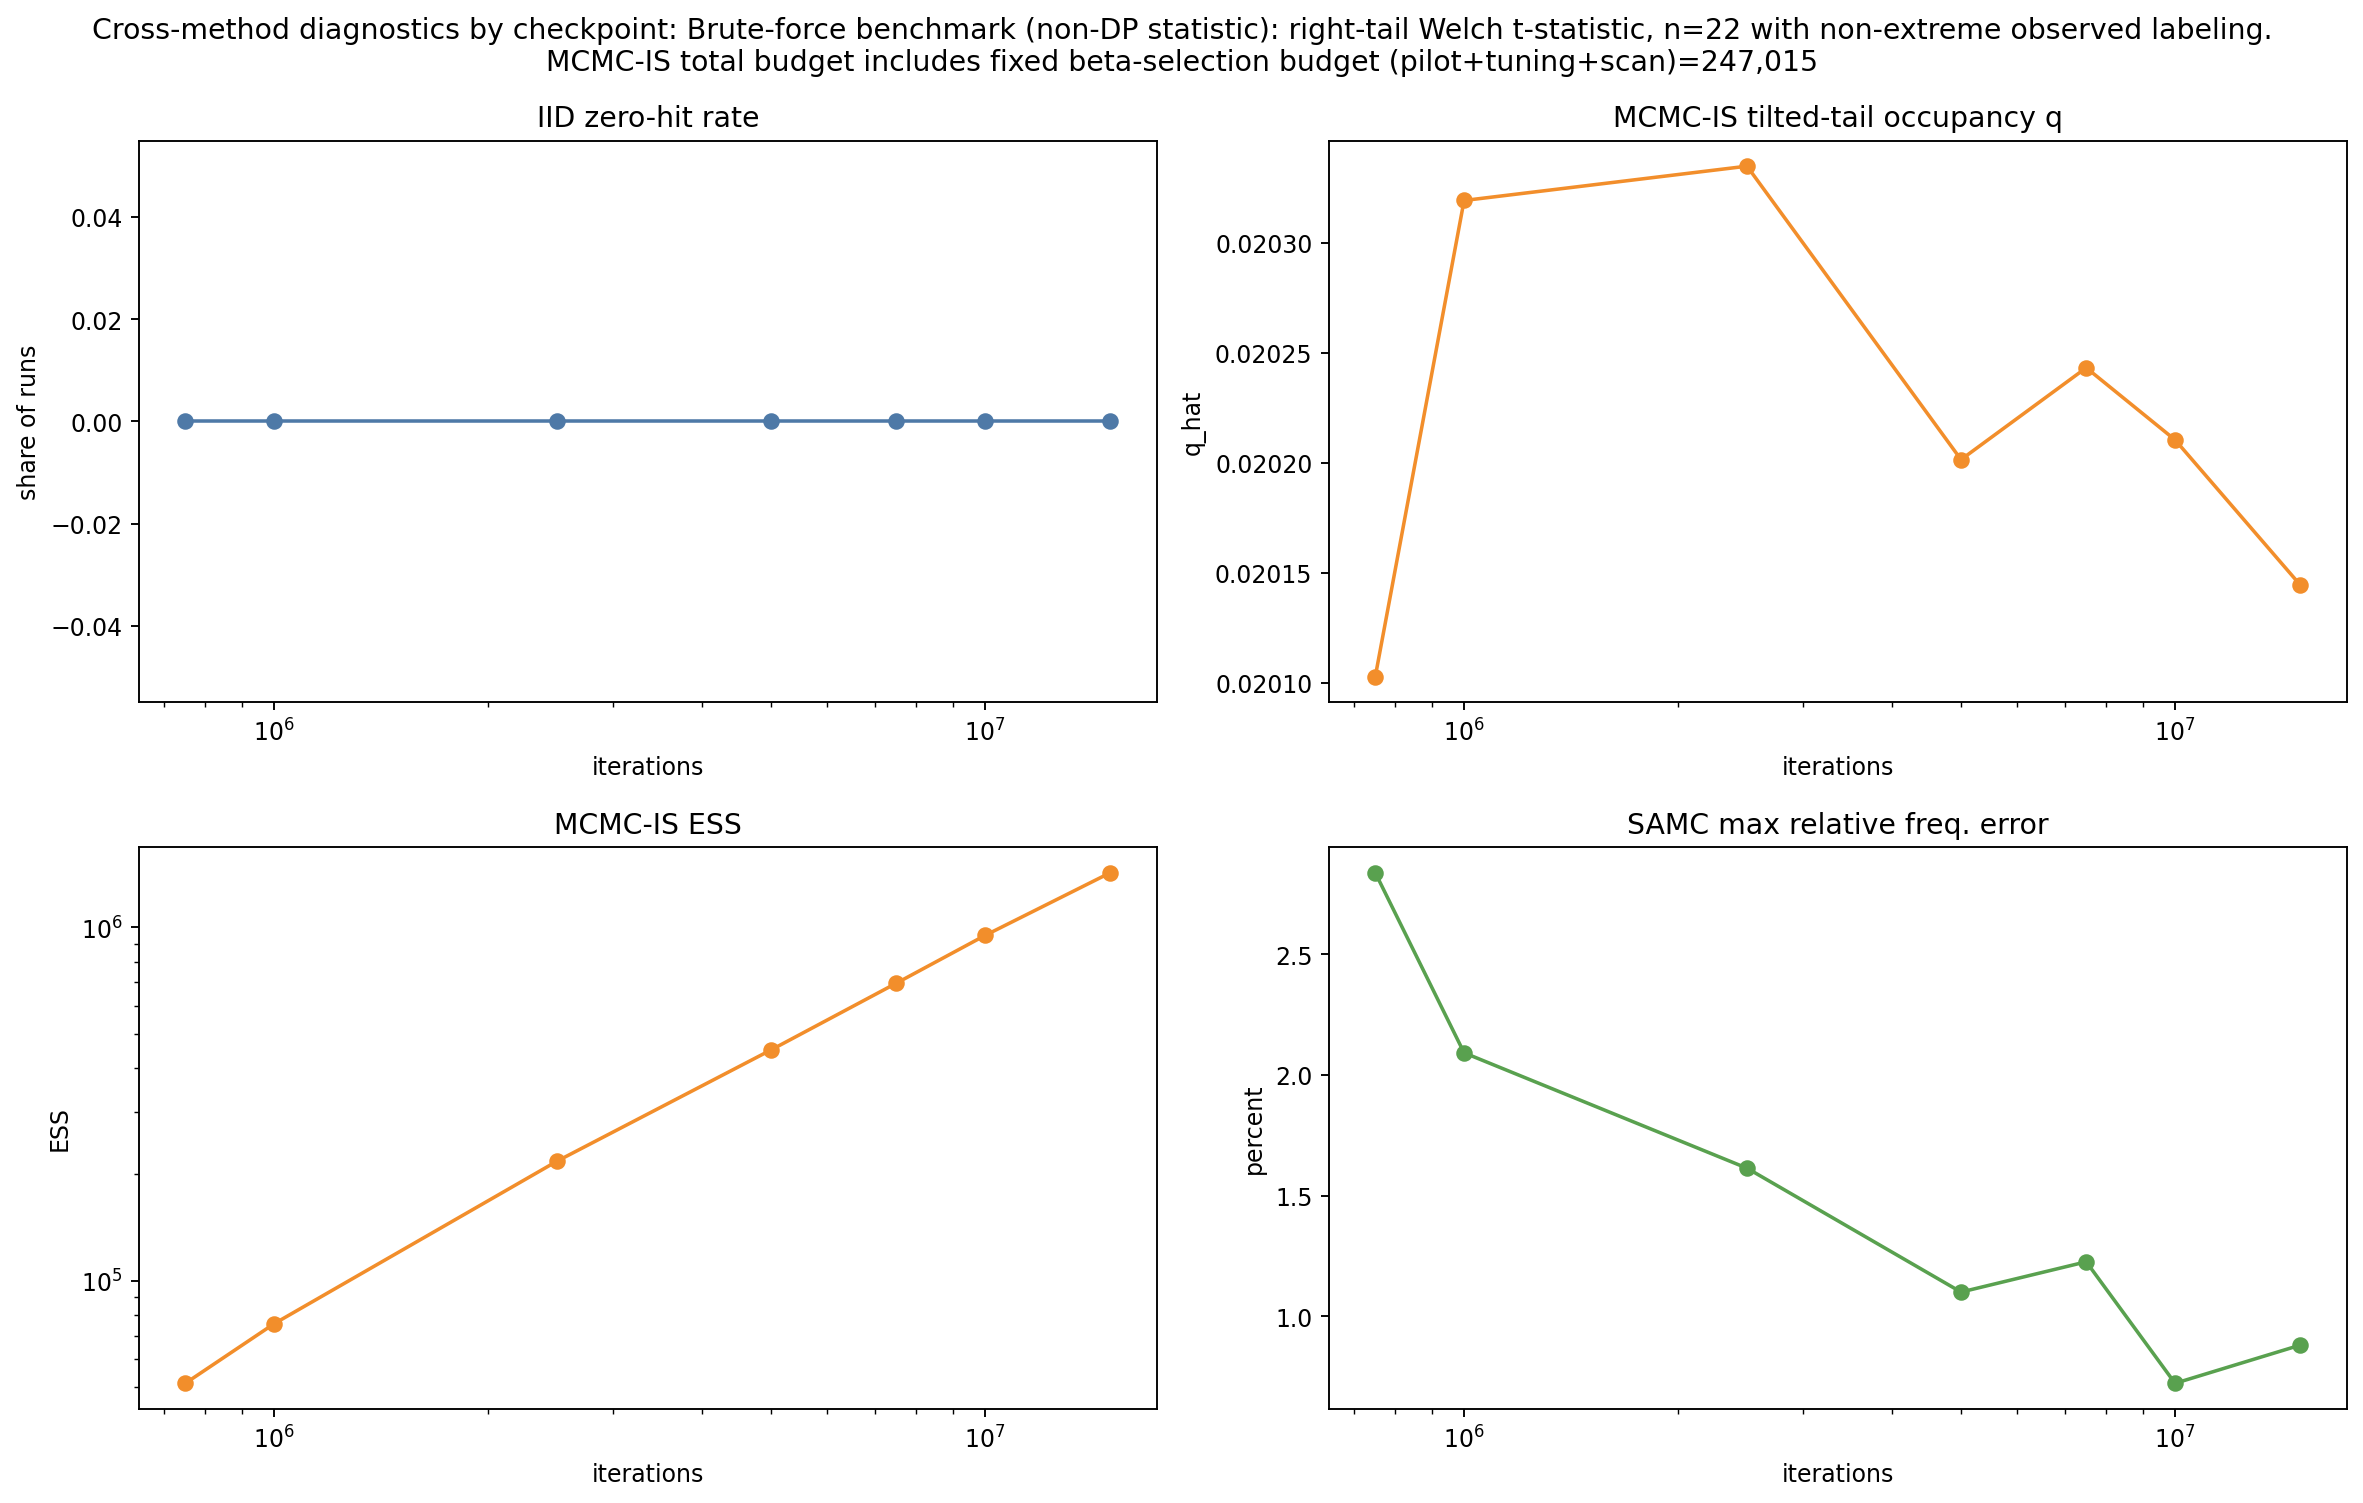

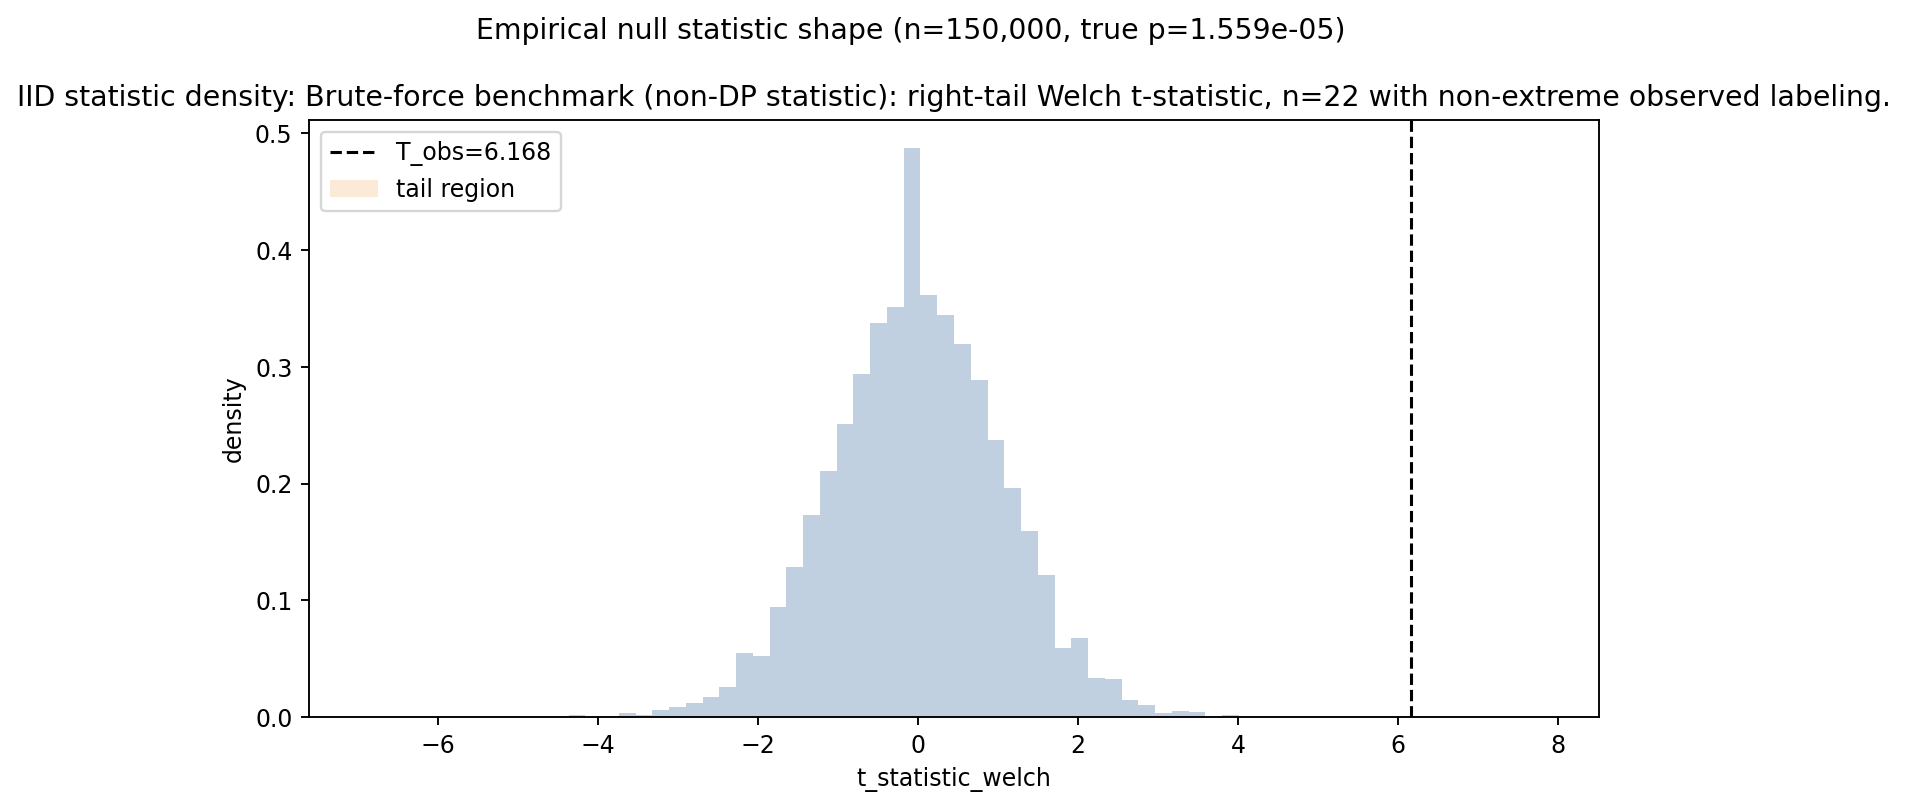

In [10]:
if SAVE_OUTPUTS and run_dir is not None:
    print(f"Saved outputs under: {run_dir}")
    for scenario in scenarios:
        scenario_dir = run_dir / scenario.key
        print(f"\n{scenario.key}")
        display(Image(filename=str(scenario_dir / "cross_method_max_budget.png")))
        display(Image(filename=str(scenario_dir / "cross_method_convergence.png")))
        display(Image(filename=str(scenario_dir / "cross_method_diagnostics.png")))
        display(Image(filename=str(scenario_dir / "iid_density.png")))
else:
    print("SAVE_OUTPUTS=False, so no saved figures to display.")

## Reload Saved Results Without Rerunning

In [ ]:
# RELOAD_SCENARIO_DIR = None
# # Example:
# # RELOAD_SCENARIO_DIR = project_root / "results" / "cross_method_notebook" / "20260306_120000_cross_method" / "gwas_additive_score_n40"

# if RELOAD_SCENARIO_DIR is not None:
#     saved = load_cross_method_saved_output(RELOAD_SCENARIO_DIR)
#     print(json.dumps({
#         "scenario": saved["metadata"]["scenario"],
#         "exact_p": saved["metadata"]["exact_p"],
#         "mcmc_beta_selection_budget": saved["metadata"]["beta_workflow"]["beta_selection_eval_total"],
#     }, indent=2))
#     regen = regenerate_cross_method_plots_from_saved(RELOAD_SCENARIO_DIR)
#     for name, path in regen.items():
#         print(name, path)
#         display(Image(filename=str(path)))
# else:
#     print("Set RELOAD_SCENARIO_DIR to a saved scenario directory to regenerate plots from disk only.")